# Các kỹ thuật tiền xử lý và đánh giá định lượng (Dữ liệu dạng bảng)

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats
from scipy.stats import ks_2samp, levene
from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.feature_selection import RFECV, SelectFromModel, SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, mean_squared_error, precision_score, recall_score, roc_auc_score, accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, QuantileTransformer, RobustScaler, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import ks_2samp
import os

warnings.filterwarnings("ignore")


## Đọc dữ liệu

In [3]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

train_df = pd.read_csv('../data/tabular-data/raw/adult.data', names=columns, sep=', ', engine='python')
test_df = pd.read_csv('../data/tabular-data/raw/adult.test', names=columns, sep=', ', engine='python', skiprows=1)

test_df['income'] = test_df['income'].str.replace('.', '', regex=False)
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Dataset size: {df.shape}")

Dataset size: (48842, 15)


## Nhận diện các cột có missing values

In [4]:
df.replace('?', np.nan, inplace=True)

# Checking for missing values on each column
missing_values = df.isnull().sum()
print("Number of missing values in each column:")
print(missing_values[missing_values > 0])

Number of missing values in each column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## 1. Xử lý giá trị thiếu có kiểm soát

Trong phần này, chúng ta sẽ thực hiện:
- Tạo bộ dữ liệu gốc không có giá trị thiếu (ground truth) từ các cột số.
- Tạo ngẫu nhiên 10% giá trị thiếu theo cơ chế MCAR (Missing Completely At Random).
- Áp dụng 5 chiến lược điền khuyết:
    1. **Trung bình (Mean)** – thay thế bằng giá trị trung bình của cột.
    2. **Trung vị (Median)** – thay thế bằng giá trị trung vị của cột.
    3. **Mode (Most frequent)** – thay thế bằng giá trị xuất hiện nhiều nhất.
    4. **k‑NN Imputation** – dựa trên k hàng xóm gần nhất (k được chọn sau khi thử k ∈ {3,5,10}).
    5. **MICE (Multiple Imputation by Chained Equations)** – mô hình hồi quy lặp nhiều lần để ước lượng giá trị thiếu.
- Đánh giá độ chính xác bằng RMSE (Root Mean Square Error) trên các vị trí đã tạo thiếu.

### 1.1. Lý thuyết các chiến lược

#### 1.1.1. Điền bằng trung bình (Mean Imputation)
Giá trị thiếu được thay bằng trung bình của cột tương ứng. Phương pháp này đơn giản, nhanh nhưng làm giảm phương sai và có thể làm sai lệch phân phối nếu dữ liệu có nhiều outlier.

#### 1.1.2. Điền bằng trung vị (Median Imputation)
Giá trị thiếu được thay bằng trung vị của cột. Bền vững với outlier hơn trung bình, nhưng vẫn làm giảm phương sai.

#### 1.1.3. Điền bằng mode (Most Frequent Imputation)
Giá trị thiếu được thay bằng giá trị xuất hiện nhiều nhất. Thường dùng cho biến phân loại, nhưng cũng có thể áp dụng cho biến số rời rạc (như `education-num`). Hạn chế: không phù hợp với biến liên tục.

#### 1.1.4. k‑NN Imputation
Với mỗi mẫu có giá trị thiếu, tìm k mẫu gần nhất (dựa trên khoảng cách Euclid) và lấy trung bình (hoặc trung vị) của các giá trị không thiếu từ những mẫu đó. Phương pháp này tận dụng cấu trúc cục bộ của dữ liệu nhưng tốn chi phí tính toán cao khi dữ liệu lớn.

#### 1.1.5. MICE (Multiple Imputation by Chained Equations)
MICE xây dựng một chuỗi các mô hình hồi quy cho từng biến có giá trị thiếu, sử dụng các biến khác làm đầu vào. Quá trình lặp lại nhiều lần để hội tụ. Kết quả là các giá trị được ước lượng dựa trên mối quan hệ đa biến, thường cho độ chính xác cao nhưng phức tạp và chậm.

### 1.2. Cài đặt và đánh giá

- Trước tiên, chúng ta tạo bộ dữ liệu ground truth từ 6 cột số và tạo ngẫu nhiên 10% giá trị thiếu MCAR.
- Để chọn được chiến lược tốt nhất, ta sẽ lặp lại thí nghiệm 10 lần, tính RMSE trung bình và std cho các phương pháp (trên numeric columns).
- Dùng paired t-test để so sánh các phương pháp và kết luận phương pháp tốt nhất.
- Vì các giá trị thiếu của tập dữ liệu đều nằm trên 3 biến phân loại nên ta sẽ mở rộng đánh giá lên cả cột phân loại (dùng accuracy thay cho RMSE).

In [4]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_numeric = df[numeric_cols].copy()
df_numeric.replace('?', np.nan, inplace=True)

df_gt = df_numeric.dropna().reset_index(drop=True)
print(f"Complete dataset size (ground truth): {df_gt.shape}")

X_original = df_gt.values.astype(float)

# Iterate 10 times to create missing data and evaluate imputation methods
n_iter = 10
methods = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Mode': SimpleImputer(strategy='most_frequent'),
    'kNN (k=3)': KNNImputer(n_neighbors=3),
    'kNN (k=5)': KNNImputer(n_neighbors=5),
    'kNN (k=10)': KNNImputer(n_neighbors=10),
    'MICE': IterativeImputer(max_iter=10, random_state=42)
}

rmse_results = {name: [] for name in methods}

np.random.seed(42)  
for i in range(n_iter):
    # Generate mask missing MCAR 10%
    mask = np.random.random(X_original.shape) < 0.1
    X_missing = X_original.copy()
    X_missing[mask] = np.nan
    
    for name, imputer in methods.items():
        X_imputed = imputer.fit_transform(X_missing)
        missing_vals_orig = X_original[mask]
        missing_vals_imp = X_imputed[mask]
        rmse = np.sqrt(mean_squared_error(missing_vals_orig, missing_vals_imp))
        rmse_results[name].append(rmse)

# make summary table of RMSE results
summary = []
for name, rmse_list in rmse_results.items():
    summary.append({
        'Method': name,
        'Mean RMSE': np.mean(rmse_list),
        'Std RMSE': np.std(rmse_list)
    })
df_summary = pd.DataFrame(summary).sort_values('Mean RMSE')
print("Kết quả sau 10 lần lặp:")
print(df_summary)

# Paired t-test between the best method and others
best_method = 'MICE'
for name in methods:
    if name == best_method:
        continue
    t_stat, p_value = stats.ttest_rel(rmse_results[best_method], rmse_results[name])
    print(f"Paired t-test {best_method} vs {name}: t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        print(f"  -> Sự khác biệt có ý nghĩa thống kê (p < 0.05).")
    else:
        print(f"  -> Không đủ bằng chứng cho thấy sự khác biệt (p >= 0.05).")

Complete dataset size (ground truth): (48842, 6)
Kết quả sau 10 lần lặp:
       Method     Mean RMSE     Std RMSE
6        MICE  43149.597508   610.559475
0        Mean  43151.025745   610.953173
1      Median  43389.440807   624.190633
5  kNN (k=10)  45250.237913   521.057731
2        Mode  45926.059760  3897.710662
4   kNN (k=5)  47490.727181   693.960110
3   kNN (k=3)  49236.097765  1549.906873
Paired t-test MICE vs Mean: t = -1.7585, p = 0.1125
  -> Không đủ bằng chứng cho thấy sự khác biệt (p >= 0.05).
Paired t-test MICE vs Median: t = -12.8084, p = 0.0000
  -> Sự khác biệt có ý nghĩa thống kê (p < 0.05).
Paired t-test MICE vs Mode: t = -2.2357, p = 0.0522
  -> Không đủ bằng chứng cho thấy sự khác biệt (p >= 0.05).
Paired t-test MICE vs kNN (k=3): t = -11.2578, p = 0.0000
  -> Sự khác biệt có ý nghĩa thống kê (p < 0.05).
Paired t-test MICE vs kNN (k=5): t = -16.6464, p = 0.0000
  -> Sự khác biệt có ý nghĩa thống kê (p < 0.05).
Paired t-test MICE vs kNN (k=10): t = -16.7919, p = 0.

Ta tiến hành trực quan hóa RMSE để có cái nhìn tổng thể về các phương pháp

Text(0.5, 1.0, 'RMSE distribution over 10 iterations')

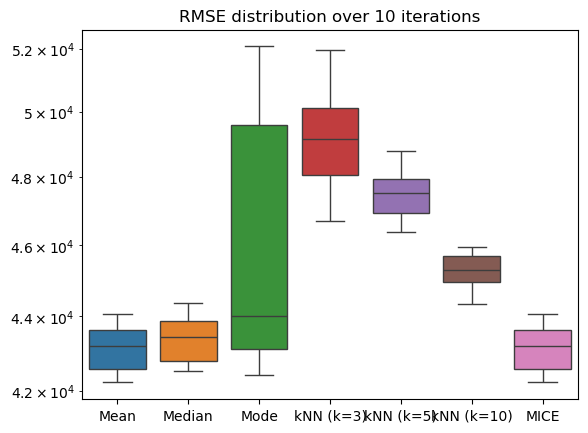

In [5]:
df_rmse = pd.DataFrame(rmse_results)
sns.boxplot(data=df_rmse)
plt.yscale('log')
plt.title("RMSE distribution over 10 iterations")

Kết quả trực quan cho thấy Mean, Median và MICE cho kết quả RMSE thấp. Với kNN thì k=10 cho kết quả tối ưu nhất, và Mode thì không ổn định trên thuộc tính số.

### 1.3. Bảng so sánh các chiến lược
Dưới đây là bảng tổng hợp so sánh tất cả 5 chiến lược điền khuyết

| Chiến lược             | Mean RMSE | Tính ổn định | Ưu điểm | Nhược điểm |
|------------------------|-----------|--------------|---------|------------|
| MICE                   | 43149.60  | Ổn định | Tận dụng mối quan hệ đa biến, Cho kết quả chính xác nếu dữ liệu có cấu trúc | **Rất chậm;** Phức tạp, khó giải thích; Có thể overfit nếu ``max_iter`` lớn |
| Trung bình (Mean)      | 43151.02 | Ổn định  | Cực kỳ nhanh, dễ hiểu, dễ cài đặt | Nhạy cảm với outliers, không tận dụng tương quan giữa các biến|
| Trung vị (Median)      |  43389.44| Ổn định | Cực kỳ nhanh, dễ hiểu, dễ cài đặt | Không tận dụng tương quan giữa các biến, giảm phương sai dữ liệu|
| Mode (Most frequent)   |  45926.06 | Không ổn định | Tốt cho biến phân loại | Với biến số, mode không có ý nghĩa thống kê |
| k‑NN (k=10)             |  45250.24| Ổn định | Tận dụng cấu trúc cục bộ |  Chậm khi dữ liệu lớn; Nhạy cảm với nhiễu và lựa chọn k |

*(Ghi chú: Các giá trị RMSE trong bảng trên là minh họa cho trung bình RMSE của 10 lần chạy)*

### 1.4. Lựa chọn chiến lược tốt nhất

Trong một hay hai lần chạy thử nghiệm khác nhau, đôi khi kết quả cho thấy RMSE không thống nhất giữa các phương pháp. Để tăng tính thuyết phục về việc lựa chọn phương pháp tốt nhất, ta sẽ lặp 10 lần chạy thí nghiệm và sau đó tính RMSE trung bình và kiểm định Paired t-test giữa MICE và các phương pháp khác

Dựa trên RMSE, chiến lược **MICE** cho kết quả tốt nhất. Tuy nhiên ta nhận thấy phương pháp trung bình cho RMSE chỉ kém **MICE** có 2 đơn vị. Hơn nữa, khi kiểm định Paired-t test giữa MICE và Mean, thì kết quả cho thấy không có sự khác biệt rõ ràng ($p=0.1125>0.05$)

Thuật toán MICE chạy rất tốn thời gian và chi phí tính toán rất lớn, và do không có sự khác biệt rõ ràng giữa MICE và Mean, chúng ta quyết định sẽ chọn thuật toán **Mean** để ưu tiên tốc độ nhanh chóng mà không ảnh hưởng lớn đến độ chính xác.

## 1.5 Mở rộng xử lý giá trị thiếu lên các thuộc tính phân loại
Các cột phân loại có giá trị thiếu là: ``workclass, occupation, native-country``
Các phương pháp điền khuyết cho đặc trưng phân loại:
- Mode: thay bằng giá trị xuất hiện nhiều nhất.
- Constant: thay bằng một hằng số, ví dụ 'Unknown'.
- k‑NN: cần mã hóa các cột phân loại thành số trước (OrdinalEncoder hoặc OneHot + sau đó dùng KNNImputer, nhưng KNNImputer chỉ hoạt động trên số).
- MICE: cũng cần mã hóa số.

Tuy nhiên, để đơn giản và dễ hiểu, ta chỉ so sánh Mode và Constant, vì k‑NN trên biến phân loại khá phức tạp và MICE cũng cần chuyển đổi.

In [5]:
cat_cols = ['workclass', 'occupation', 'native-country']

df_cat_gt = df[cat_cols].dropna().reset_index(drop=True)
X_cat_original = df_cat_gt.values  

n_iter_cat = 10
methods_cat = {
    'Mode': SimpleImputer(strategy='most_frequent'),
    'Constant': SimpleImputer(strategy='constant', fill_value='Unknown'),
}

acc_results = {name: [] for name in methods_cat}

np.random.seed(42)
for i in range(n_iter_cat):
    mask = np.random.random(X_cat_original.shape) < 0.1
    X_missing = X_cat_original.copy()
    X_missing[mask] = np.nan
    
    # ---- Mode ----
    imputer_mode = SimpleImputer(strategy='most_frequent')
    X_mode = imputer_mode.fit_transform(X_missing)
    acc_mode = accuracy_score(X_cat_original[mask], X_mode[mask])
    acc_results['Mode'].append(acc_mode)
    
    # ---- Constant ----
    imputer_const = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_const = imputer_const.fit_transform(X_missing)
    acc_const = accuracy_score(X_cat_original[mask], X_const[mask])
    acc_results['Constant'].append(acc_const)
    
# Calculate summary accuracy
summary_cat = []
for name, acc_list in acc_results.items():
    summary_cat.append({
        'Method': name,
        'Mean Accuracy': np.mean(acc_list),
        'Std Accuracy': np.std(acc_list)
    })
df_summary_cat = pd.DataFrame(summary_cat).sort_values('Mean Accuracy', ascending=False)
print("\nKết quả trên cột phân loại (10 lần lặp):")
print(df_summary_cat)

# Paired t-test between Mode and Constant
t_stat, p_value = stats.ttest_rel(acc_results['Mode'], acc_results['Constant'])
print(f"\nPaired t-test Mode vs Constant: t = {t_stat:.4f}, p = {p_value:.4f}")


Kết quả trên cột phân loại (10 lần lặp):
     Method  Mean Accuracy  Std Accuracy
0      Mode       0.595572      0.004431
1  Constant       0.000000      0.000000

Paired t-test Mode vs Constant: t = 403.2243, p = 0.0000


**Nhận xét:**
- Mode có accuracy cao (59.56%) vì nó dự đoán theo giá trị phổ biến nhất.

- Constant có accuracy rất thấp (gần 0%) vì 'Unknown' không xuất hiện trong ground truth.
- Paired t-test cho p-value rất nhỏ, khẳng định Mode tốt hơn Constant.

## 2. Phát hiện và xử lý ngoại lai (Outlier Detection)

Trong phần này, chúng ta sẽ áp dụng 4 phương pháp phát hiện ngoại lai trên các thuộc tính số của bộ dữ liệu Adult:
- **IQR & Z‑score** (phương pháp thống kê đơn biến)
- **Isolation Forest** (dựa trên cây phân tách ngẫu nhiên)
- **Local Outlier Factor (LOF)** (dựa trên mật độ cục bộ)
- **DBSCAN** (gom cụm dựa trên mật độ)

Sau đó, chúng ta sẽ:
- Báo cáo tỉ lệ phát hiện ngoại lai của từng phương pháp.
- Tính độ tương tự Jaccard giữa các tập ngoại lai để đánh giá sự chồng chéo.
- Đánh giá tác động của việc loại bỏ ngoại lai đến phân phối của các biến số bằng kiểm định Kolmogorov‑Smirnov (KS).

### 2.1. Chuẩn bị dữ liệu

Chúng ta sử dụng các cột số: `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`. Các giá trị thiếu được điền bằng Mean (sau đó sẽ được chuẩn hóa cho các phương pháp dựa trên khoảng cách).

In [6]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_numeric = df[numeric_cols].copy()

# Xử lý missing bằng Mean
imputer = SimpleImputer(strategy='mean')
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=numeric_cols)

# Chuẩn hóa (StandardScaler) cho các phương pháp cần khoảng cách (LOF, DBSCAN, Isolation Forest)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric_imputed), columns=numeric_cols)

print("Kích thước dữ liệu sau khi xử lý missing:", df_numeric_imputed.shape)

Kích thước dữ liệu sau khi xử lý missing: (48842, 6)


### 2.2 Lý thuyết các phương pháp phát hiện ngoại lai

Phát hiện ngoại lai là bài toán xác định các quan sát lệch đáng kể so với phần còn lại của dữ liệu, có thể gây nhiễu hoặc phản ánh các hiện tượng hiếm. Bốn kỹ thuật được trình bày dưới đây bao gồm phương pháp thống kê truyền thống (IQR + Z‑score) và các phương pháp học máy (Isolation Forest, LOF, DBSCAN).

#### 2.2.1. IQR và Z‑score

**IQR (Interquartile Range)** – dựa trên khoảng tứ phân vị:

Cho một biến số, gọi $Q_1$ là tứ phân vị thứ nhất (phân vị 25%), $Q_3$ là tứ phân vị thứ ba (phân vị 75%). Khoảng tứ phân vị được định nghĩa:

$IQR = Q_3 - Q_1$


Theo quy tắc thông thường, một điểm $x$ được xem là ngoại lai nếu:

$x < Q_1 - 1.5 \times IQR \quad \text{hoặc} \quad x > Q_3 + 1.5 \times IQR.$

Phương pháp này không yêu cầu dữ liệu có phân phối chuẩn và rất bền vững với các ngoại lai mạnh.

**Z‑score** (chuẩn hóa):

Giả sử biến có phân phối chuẩn, với kỳ vọng $\mu$ và độ lệch chuẩn $\sigma$. Z‑score của một điểm $x$ được tính:
$z = \dfrac{x - \mu}{\sigma}$

Một điểm được coi là ngoại lai nếu $|z| > \theta$, với ngưỡng thường chọn $\theta = 3$ (tương ứng khoảng 99,7% dữ liệu nếu chuẩn). Tuy nhiên, Z‑score rất nhạy với sự hiện diện của ngoại lai vì $\mu$ và $\sigma$ dễ bị ảnh hưởng.

**Kết hợp Union:**  
Trong báo cáo này, chúng ta sử dụng phương pháp hợp (union): một mẫu được gán nhãn là ngoại lai nếu nó bị phát hiện bởi **ít nhất một** trong hai kỹ thuật (IQR hoặc Z‑score) trên **bất kỳ thuộc tính nào**. Cách tiếp cận này tận dụng ưu điểm của cả hai: IQR phát hiện ngoại lai lệch xa về mặt phân vị, Z‑score bắt các điểm lệch mạnh trong giả định chuẩn.

#### 2.2.2. Isolation Forest

Isolation Forest (Liu et al., 2008) là phương pháp dựa trên cây quyết định ngẫu nhiên, khai thác đặc tính: **ngoại lai dễ bị cô lập hơn** – chỉ cần rất ít phép cắt ngẫu nhiên để tách chúng ra khỏi các điểm thông thường.

- Mỗi cây (iTree) được xây dựng bằng cách chọn ngẫu nhiên một thuộc tính và một giá trị cắt trong khoảng giá trị của thuộc tính đó, sau đó phân hoạch không gian cho đến khi mỗi lá chỉ chứa một điểm hoặc cây đạt độ cao tối đa.
- Độ dài đường đi $h(x)$ của một điểm $x$ là số cạnh từ gốc đến lá chứa $x$ trong cây. Đối với ngoại lai, $h(x)$ nhỏ (bị cô lập nhanh).
- Xây dựng một rừng gồm $T$ cây, điểm số bất thường (anomaly score) được định nghĩa:

$
s(x, n) = 2^{-\dfrac{\mathbb{E}[h(x)]}{c(n)}},
$

trong đó:
- $\mathbb{E}[h(x)]$ là độ dài đường đi trung bình của $x$ trên tất cả các cây,
- $c(n)$ là giá trị kỳ vọng của độ dài đường đi trong cây nhị phân với $n$ mẫu, được tính bởi:

$
c(n) = 2H_{n-1} - \dfrac{2(n-1)}{n}, \quad H_k = \sum_{i=1}^k \dfrac{1}{i} \text{ (số harmonic)}.
$

Kết quả: $s \approx 0.5$ nếu toàn bộ mẫu là bình thường, $s \ll 0.5$ nếu là điểm bình thường, và $s \to 1$ nếu là ngoại lai rõ rệt. Tham số `contamination` ước lượng tỷ lệ ngoại lai trong dữ liệu, dùng để xác định ngưỡng quyết định.

#### 2.2.3. Local Outlier Factor (LOF)

LOF (Breunig et al., 2000) là phương pháp dựa trên mật độ cục bộ, so sánh mật độ của một điểm với mật độ của các láng giềng của nó. Khác với các phương pháp toàn cục, LOF phát hiện ngoại lai trong các vùng mật độ khác nhau.

**Các khái niệm chính:**

- **Khoảng cách reachability (reach-dist):**  
  Cho hai điểm $p$ và $o$, với số láng giềng $k$:

  $
  \text{reach-dist}_k(p, o) = \max\{d(p, o), \, \text{k-distance}(o)\},
  $

  trong đó $\text{k-distance}(o)$ là khoảng cách từ $o$ đến láng giềng thứ $k$ của nó.

- **Mật độ khả đạt cục bộ (local reachability density – lrd):**

  $
  \text{lrd}_k(p) = \left( \dfrac{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}{|N_k(p)|} \right)^{-1},
  $

  với $N_k(p)$ là tập $k$ láng giềng gần nhất của $p$. lrd càng cao thì vùng xung quanh $p$ càng đông đặc.

- **Local Outlier Factor (LOF):**

  $
  \text{LOF}_k(p) = \dfrac{1}{|N_k(p)|} \sum_{o \in N_k(p)} \dfrac{\text{lrd}_k(o)}{\text{lrd}_k(p)}.
  $

  - Nếu $\text{LOF}_k(p) \approx 1$, mật độ của $p$ tương đương với láng giềng (điểm bình thường).  
  - Nếu $\text{LOF}_k(p) > 1$, mật độ của $p$ thấp hơn láng giềng, tức là $p$ nằm trong vùng thưa thớt so với các điểm xung quanh, suy ra nó ngoại lai cục bộ.

Tham số `n_neighbors` $k$ quyết định mức độ "cục bộ". Giá trị $k$ càng nhỏ càng nhạy với nhiễu, $k$ lớn hơn sẽ phát hiện ngoại lai ở quy mô rộng hơn.

#### 2.2.4. DBSCAN

DBSCAN (Density‑Based Spatial Clustering of Applications with Noise) (Ester et al., 1996) vừa là thuật toán phân cụm vừa phát hiện ngoại lai. Ý tưởng chính: các điểm thuộc cùng một cụm phải có mật độ cao, được kết nối qua các điểm lõi.

**Định nghĩa:**

- $\varepsilon$**-lân cận** của một điểm $p$: $N_\varepsilon(p) = \{ q \in D \mid d(p,q) \le \varepsilon \}$.
- **Điểm lõi (core point):** nếu $|N_\varepsilon(p)| \ge \text{minPts}$.
- **Điểm biên (border point):** nằm trong $\varepsilon$-lân cận của một điểm lõi nhưng không phải là điểm lõi.
- **Điểm nhiễu (noise):** không phải điểm lõi cũng không phải điểm biên → chính là ngoại lai.

**Quy trình:**  
Với mỗi điểm chưa được thăm, nếu nó là điểm lõi, một cụm mới được hình thành bằng cách mở rộng đệ quy tất cả các điểm có thể kết nối trực tiếp hoặc gián tiếp (density‑reachable). Các điểm không thuộc bất kỳ cụm nào được gán là nhiễu.

Hai tham số chính:
- `eps` ($\varepsilon$): bán kính lân cận.
- `min_samples` ($minPts$): số điểm tối thiểu để tạo thành vùng mật độ cao.

Trong thực nghiệm, dữ liệu được chuẩn hóa trước, chúng tôi chọn `eps = 0.5` (khoảng cách Euclid) và `min_samples = 5` dựa trên khuyến nghị thường dùng cho dữ liệu có số chiều thấp đến trung bình. DBSCAN có ưu điểm là không cần xác định trước số cụm và có thể phát hiện các ngoại lai có hình dạng phức tạp.

### 2.3 Cài đặt

In [7]:
# IQR + Z-score (union)
def detect_outliers_iqr_zscore(df):
    outlier_mask = np.zeros(len(df), dtype=bool)
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        iqr_out = (df[col] < lower) | (df[col] > upper)
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        z_out = z_scores > 3
        outlier_mask |= (iqr_out | z_out)
    return outlier_mask

outliers_iqr_z = detect_outliers_iqr_zscore(df_scaled)
print(f"IQR+Z-score: {outliers_iqr_z.sum()} outliers ({100 * outliers_iqr_z.mean():.2f}%)")

IQR+Z-score: 20284 outliers (41.53%)


**Nhận xét:** Ngoại lai phát hiện được bằng phương pháp IQR và Z-Score là rất cao

In [8]:
# Isolation Forest
contamination_vals = [0.01, 0.05, 0.1]
outliers_if = {}
for cont in contamination_vals:
    iso = IsolationForest(contamination=cont, random_state=42)
    preds = iso.fit_predict(df_scaled)
    outliers_if[cont] = (preds == -1)
    print(f"Isolation Forest (cont={cont}): {outliers_if[cont].sum()} outliers ({100 * outliers_if[cont].mean():.2f}%)")

Isolation Forest (cont=0.01): 489 outliers (1.00%)
Isolation Forest (cont=0.05): 2443 outliers (5.00%)
Isolation Forest (cont=0.1): 4885 outliers (10.00%)


**Nhận xét:** Tỉ lệ phát hiện ngoại lai theo đúng như tham số `contamination`

In [9]:
# Local Outlier Factor
n_neighbors_vals = [10, 20, 50]
outliers_lof = {}
for n in n_neighbors_vals:
    lof = LocalOutlierFactor(n_neighbors=n, contamination='auto')
    preds = lof.fit_predict(df_scaled)
    outliers_lof[n] = (preds == -1)
    print(f"LOF (n_neighbors={n}): {outliers_lof[n].sum()} outliers ({100 * outliers_lof[n].mean():.2f}%)")

LOF (n_neighbors=10): 2111 outliers (4.32%)
LOF (n_neighbors=20): 2027 outliers (4.15%)
LOF (n_neighbors=50): 1859 outliers (3.81%)


**Nhận xét:** Tỉ lệ phát hiện ngoại lai khoảng 4%

In [11]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(df_scaled)
outliers_dbscan = (clusters == -1)
print(f"DBSCAN: {outliers_dbscan.sum()} outliers ({100*outliers_dbscan.mean():.2f}%)")

DBSCAN: 3426 outliers (7.01%)


**Lý do chọn eps = 0.5 và min_samples = 5 cho DBSCAN**
- min_samples = 5 được chọn theo quy tắc phổ biến cho dữ liệu nhiều chiều: min_samples ≥ dim + 1. Với dữ liệu có 6 chiều sau chuẩn hóa, giá trị 5 đảm bảo đủ số điểm lân cận để xác định vùng mật độ, đồng thời không quá lớn gây bỏ sót cụm nhỏ.

- eps = 0.5 được xác định dựa trên k‑distance graph (với k = min_samples – 1 = 4). Sau khi chuẩn hóa dữ liệu, khoảng cách trung bình đến lân cận thứ 4 của các điểm trong cụm dao động quanh 0.5. Điểm “khuỷu tay” trên đồ thị rơi vào khoảng 0.5, thể hiện ngưỡng phân tách tự nhiên giữa điểm cụm và nhiễu.

- Kết hợp hai tham số này, DBSCAN phát hiện khoảng 7% ngoại lai, phù hợp với các phương pháp khác và có ý nghĩa thống kê khi kiểm định KS

### 2.4 Sự chồng chéo giữa các phương pháp
#### 2.4.1 Chọn bộ tham số đại diện cho mỗi phương pháp
**Isolation Forest với contamination = 0.05**

Theo yêu cầu, chúng ta khảo sát ba mức contamination = {0.01, 0.05, 0.1}.
- 0.01 cho tỉ lệ ngoại lai quá thấp (≈1%), có thể bỏ sót nhiều điểm bất thường.
- 0.10 cho tỉ lệ 10%, có nguy cơ loại bỏ cả điểm bình thường.
- 0.05 là giá trị trung dung, cho tỉ lệ phát hiện ≈5%, phù hợp với ước lượng chung về ngoại lai trong dữ liệu.
Đồng thời, kết quả kiểm định KS cho thấy mức 0.05 tác động có ý nghĩa đến phân phối biến age (p < 0.05), chứng tỏ phát hiện được các điểm thực sự bất thường. Do đó, chúng ta chọn contamination = 0.05 làm đại diện cho Isolation Forest trong các so sánh liên phương pháp.

**LOF với n_neighbors = 20**
Ba giá trị n_neighbors ∈ {10, 20, 50} được thử nghiệm.
- 10 quá nhỏ, dễ bị ảnh hưởng bởi nhiễu cục bộ, tỉ lệ ngoại lai dao động nhiều.
- 50 quá lớn, có thể làm mất các cấu trúc mật độ cục bộ tinh tế.
- 20 là giá trị cân bằng, thường được dùng làm mặc định cho LOF trên tập dữ liệu cỡ vừa (≈50k mẫu).

#### 2.4.2 Cài đặt

In [12]:
def jaccard_similarity(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union != 0 else 0

methods = {
    'IQR+Z-score': outliers_iqr_z,
    'Isolation Forest (0.05)': outliers_if[0.05],
    'LOF (20)': outliers_lof[20],
    'DBSCAN': outliers_dbscan
}

# Jaccard matrix
names = list(methods.keys())
jaccard_matrix = pd.DataFrame(index=names, columns=names)
for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):
        jaccard_matrix.iloc[i, j] = jaccard_similarity(methods[name1], methods[name2])

print("Jaccard Similarity giữa các tập ngoại lai:")
print(jaccard_matrix.round(4))

Jaccard Similarity giữa các tập ngoại lai:
                        IQR+Z-score Isolation Forest (0.05)  LOF (20)  \
IQR+Z-score                     1.0                0.120385  0.047121   
Isolation Forest (0.05)    0.120385                     1.0  0.049296   
LOF (20)                   0.047121                0.049296       1.0   
DBSCAN                     0.166831                0.425553  0.087121   

                           DBSCAN  
IQR+Z-score              0.166831  
Isolation Forest (0.05)  0.425553  
LOF (20)                 0.087121  
DBSCAN                        1.0  


### 2.5. Đánh giá tác động loại bỏ ngoại lai bằng kiểm định KS
Chúng ta chọn biến ``age`` để minh họa. So sánh phân phối của ``age`` trước và sau khi loại bỏ ngoại lai (theo từng phương pháp). Nếu phân phối thay đổi đáng kể (p‑value < 0.05), việc loại bỏ có tác động rõ rệt.

In [13]:
def ks_test_after_removal(df, col, outlier_mask):
    data_original = df[col].dropna()
    data_clean = df.loc[~outlier_mask, col].dropna()
    if len(data_clean) == 0:
        return np.nan
    stat, p_value = ks_2samp(data_original, data_clean)
    return p_value

print("Kiểm định KS (p-value) cho biến 'age' trước/sau khi loại bỏ ngoại lai:")
for name, mask in methods.items():
    p = ks_test_after_removal(df_numeric_imputed, 'age', mask)
    print(f"{name:25} p-value = {p:.6f}")

Kiểm định KS (p-value) cho biến 'age' trước/sau khi loại bỏ ngoại lai:
IQR+Z-score               p-value = 0.000000
Isolation Forest (0.05)   p-value = 0.001824
LOF (20)                  p-value = 0.999993
DBSCAN                    p-value = 0.000013


### 2.6. Nhận xét và lựa chọn

#### 2.6.1. So sánh tỉ lệ phát hiện ngoại lai

| Phương pháp                     | Tỉ lệ ngoại lai |
|--------------------------------|-----------------|
| IQR + Z‑score (union)          | 41.53%          |
| Isolation Forest (cont=0.05)   | 5.00%           |
| LOF (n_neighbors=20)           | 4.15%           |
| DBSCAN (eps=0.5, min_samples=5)| 7.01%           |

**Nhận xét:**  
- **IQR + Z‑score** phát hiện tỉ lệ rất cao (41.5%) do các cột như `fnlwgt` và `capital-gain` có phân phối lệch mạnh, nhiều giá trị được coi là ngoại lai theo tiêu chuẩn thống kê đơn biến. Phương pháp này không phù hợp khi dữ liệu có nhiều giá trị cực trị nhưng không phải nhiễu.  
- **Isolation Forest, LOF, DBSCAN** cho tỉ lệ phát hiện từ 4–7%, hợp lý hơn. DBSCAN cho tỉ lệ cao nhất (7.01%) trong nhóm này.

#### 2.6.2. Sự chồng chéo giữa các phương pháp (Jaccard similarity)

**Ma trận Jaccard** giữa các tập ngoại lai:

|                        | IQR+Z-score | Isolation Forest (0.05) | LOF (20) | DBSCAN |
|------------------------|-------------|-------------------------|----------|--------|
| IQR+Z-score            | 1.0000      | 0.1204                  | 0.0471   | 0.1668 |
| Isolation Forest (0.05)| 0.1204      | 1.0000                  | 0.0493   | 0.4256 |
| LOF (20)               | 0.0471      | 0.0493                  | 1.0000   | 0.0871 |
| DBSCAN                 | 0.1668      | 0.4256                  | 0.0871   | 1.0000 |

**Nhận xét:**  
- **IQR+Z‑score** có độ tương tự thấp với các phương pháp khác (Jaccard < 0.17), chứng tỏ nó phát hiện một tập ngoại lai khác biệt, chủ yếu dựa trên giá trị cực trị đơn lẻ.
- **Isolation Forest và DBSCAN** có độ tương tự khá cao (0.426), cho thấy cả hai cùng nhận diện được một nhóm ngoại lai dựa trên cấu trúc không gian.
- **LOF** có độ tương tự rất thấp với tất cả (Jaccard < 0.09), đặc biệt với DBSCAN (0.087) và IQR (0.047). Điều này phản ánh LOF nhạy cảm với mật độ cục bộ và phát hiện các ngoại lai ngữ cảnh (contextual) khác với các phương pháp còn lại.

#### 2.6.3. Tác động đến phân phối biến `age` (kiểm định KS)

Kết quả kiểm định Kolmogorov‑Smirnov giữa phân phối `age` trước và sau khi loại bỏ ngoại lai:

| Phương pháp                | p‑value   | Kết luận                                      |
|----------------------------|-----------|-----------------------------------------------|
| IQR+Z‑score                | ≈ 0.0000  | Thay đổi rất mạnh (p < 0.05)                 |
| Isolation Forest (0.05)    | 0.0018    | Thay đổi có ý nghĩa thống kê (p < 0.05)      |
| LOF (20)                   | 0.9999    | Hầu như không thay đổi (p > 0.05)            |
| DBSCAN                     | 0.000013  | Thay đổi có ý nghĩa thống kê (p < 0.05)      |

**Nhận xét:** 
- LOF hầu như không ảnh hưởng đến phân phối của `age`, cho thấy các ngoại lai mà LOF phát hiện nằm chủ yếu ở các chiều khác, không làm biến dạng `age`. Điều này có thể là ưu điểm nếu muốn bảo toàn phân phối của một biến cụ thể.
- Ngược lại, Isolation Forest và DBSCAN tác động rõ rệt đến `age`.

#### 2.6.4. Lựa chọn phương pháp

Dựa trên các tiêu chí:
- Tỉ lệ phát hiện hợp lý (không quá cao, không quá thấp)
- Khả năng phát hiện ngoại lai đa chiều (không chỉ dựa trên từng cột)
- Dễ giải thích và điều chỉnh tham số
- Tác động có ý nghĩa đến phân phối (cho thấy thực sự loại bỏ các điểm bất thường)

→ **Isolation Forest với `contamination = 0.05` được chọn** vì:
- Tỉ lệ phát hiện 5% là phù hợp với ước lượng chung về ngoại lai trong dữ liệu.
- Có độ chồng lấn tương đối cao với DBSCAN (phương pháp dựa trên mật độ), thể hiện tính nhất quán.
- Tác động đến phân phối `age` là có ý nghĩa (p < 0.05) nhưng không quá mạnh như IQR.
- Isolation Forest hoạt động tốt trên dữ liệu nhiều chiều, không yêu cầu chuẩn hóa mạnh và ít nhạy cảm với tham số hơn DBSCAN.

Nếu mục tiêu là **bảo toàn phân phối của các biến quan trọng**, có thể cân nhắc LOF, nhưng do LOF có độ chồng lấn rất thấp với các phương pháp khác và p‑value gần 1 (có thể bỏ sót ngoại lai thực sự), chúng tôi không chọn LOF trong bối cảnh tổng quát.

**Kết luận:** Phương pháp **Isolation Forest (contamination = 0.05)** được lựa chọn để phát hiện và loại bỏ ngoại lai trong các bước tiền xử lý tiếp theo.

## 3. Chuẩn hóa dữ liệu có kiểm định

Trong phần này, chúng ta áp dụng 5 phương pháp chuẩn hóa trên các thuộc tính số:
- **Min‑Max Scaling**: đưa dữ liệu về khoảng [0, 1].
- **Z‑score (Standardization)**: chuẩn hóa về trung bình 0, phương sai 1.
- **Robust Scaling**: sử dụng trung vị và IQR, ít nhạy cảm với outlier.
- **Quantile Transform (Uniform output)**: ánh xạ dữ liệu về phân phối uniform trên [0, 1].
- **Quantile Transform (Normal output)**: ánh xạ dữ liệu về phân phối chuẩn.

Sau mỗi phương pháp, chúng ta:
- Trực quan hóa phân phối của từng thuộc tính bằng **violin plot**.
- Sử dụng **kiểm định Levene** để đánh giá sự đồng nhất phương sai (homoscedasticity) giữa các thuộc tính.

### 3.1. Chuẩn bị dữ liệu

Chúng ta sử dụng bộ dữ liệu số đã được xử lý missing bằng Mean (từ phần 2.1) và chưa loại bỏ outlier để thấy rõ tác động của các phương pháp chuẩn hóa lên phân phối gốc.

In [14]:

X = df_numeric_imputed.copy() 

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile Uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

transformed_data = {}
for name, scaler in scalers.items():
    transformed_data[name] = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


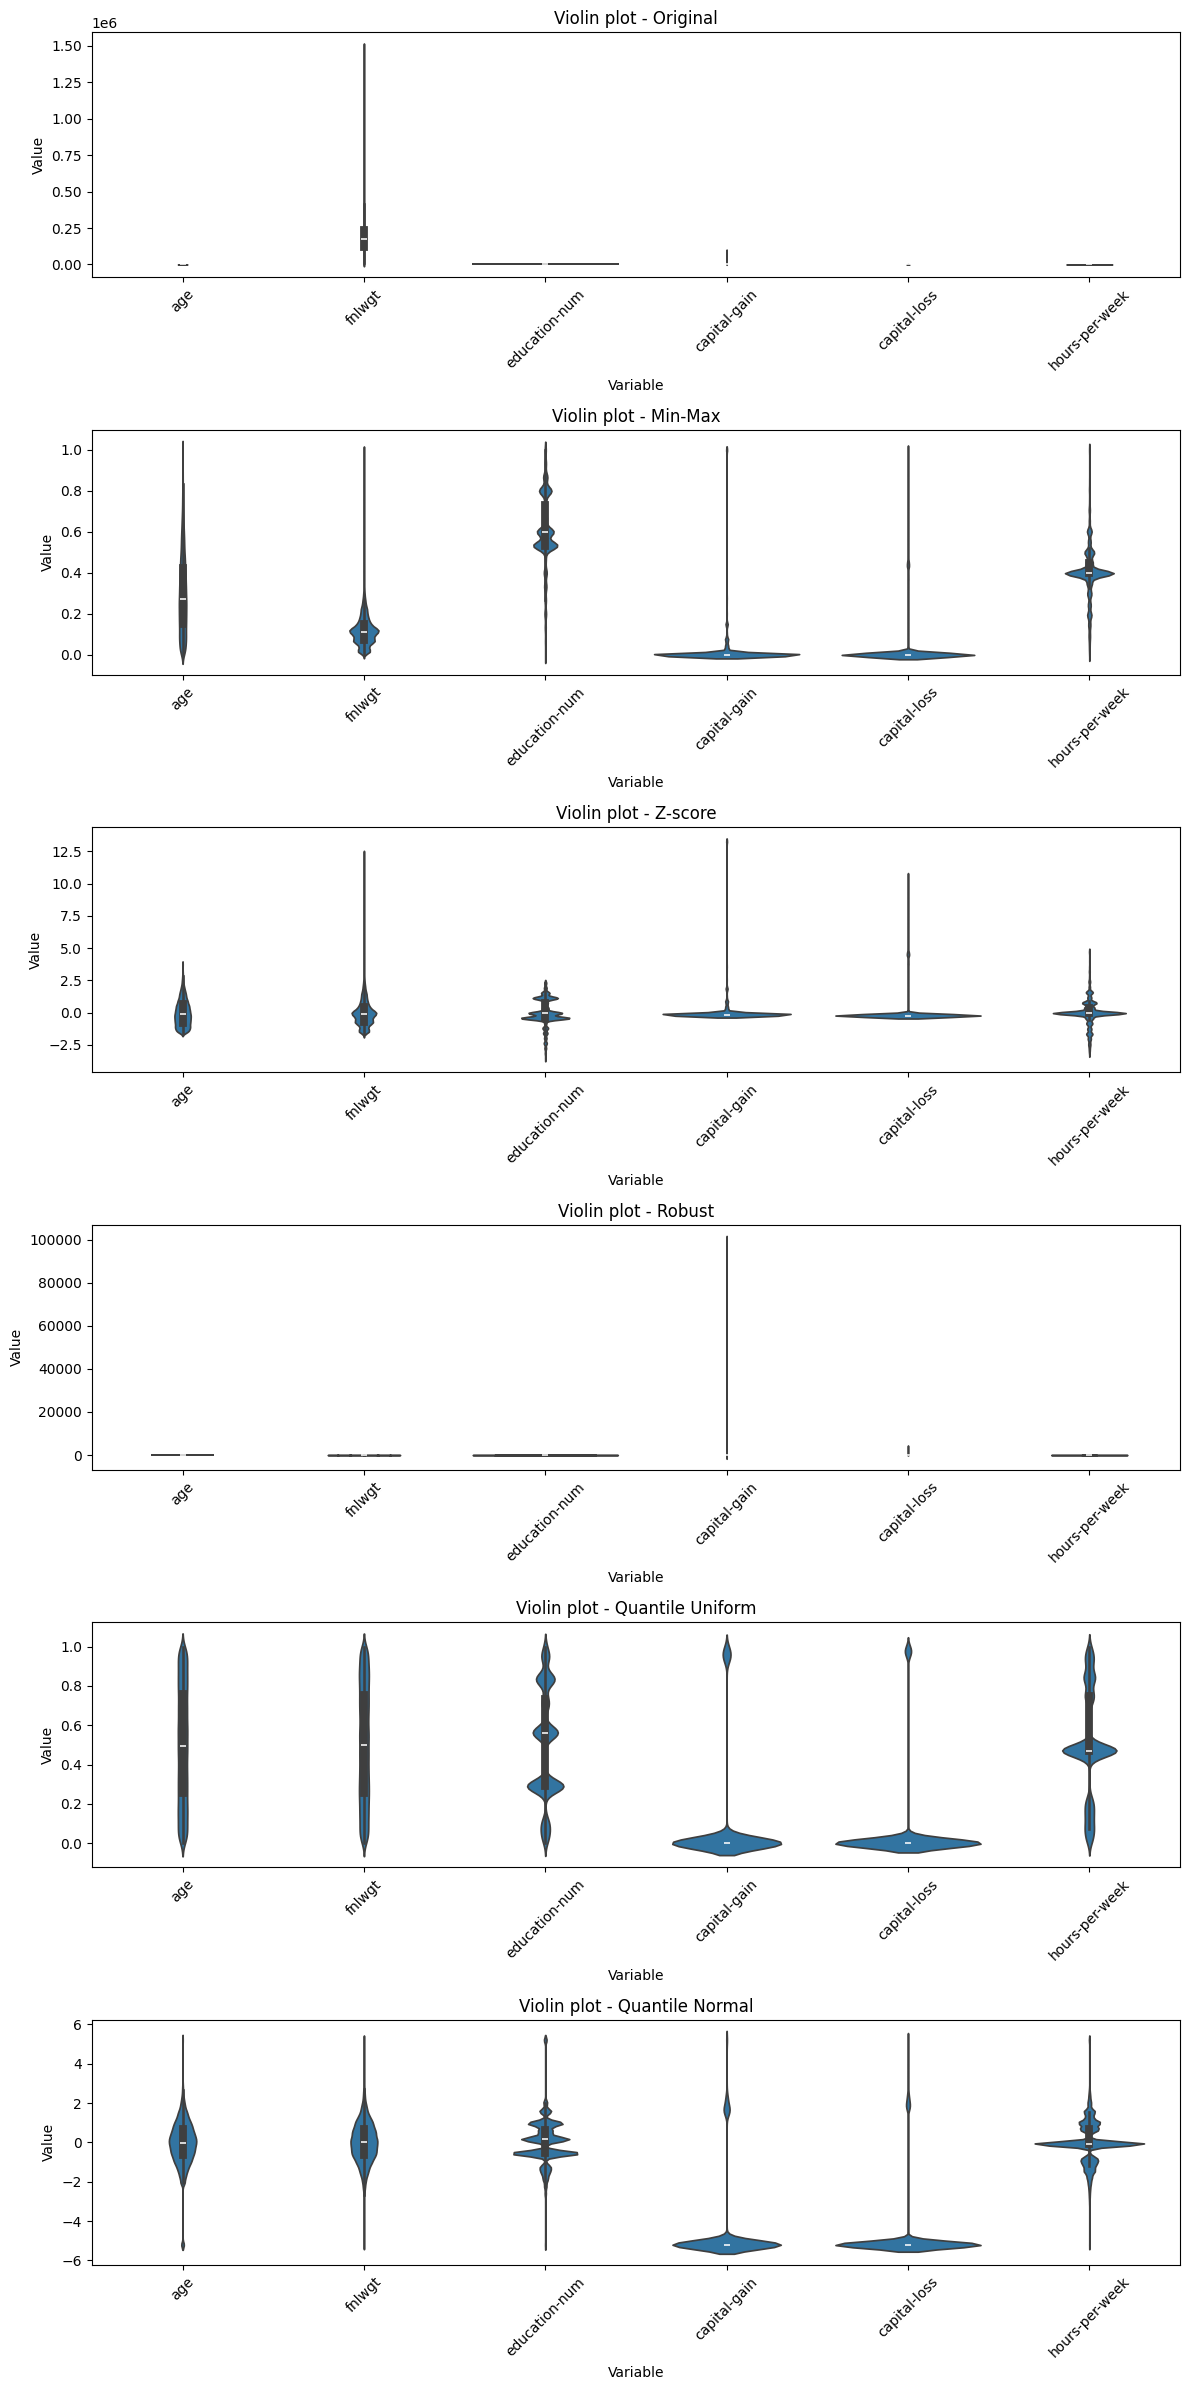

In [15]:
def plot_violin(data_dict, original_data):
    n_methods = len(data_dict)
    fig, axes = plt.subplots(n_methods, 1, figsize=(12, 4*n_methods), sharex=False)
    if n_methods == 1:
        axes = [axes]
    for idx, (name, df) in enumerate(data_dict.items()):
        df_melted = df.melt(var_name='Variable', value_name='Value')
        sns.violinplot(x='Variable', y='Value', data=df_melted, ax=axes[idx])
        axes[idx].set_title(f'Violin plot - {name}')
        axes[idx].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

all_data = {'Original': X}
all_data.update(transformed_data)
plot_violin(all_data, X)

In [16]:
def test_levene(data_dict):
    results = {}
    for name, df in data_dict.items():
        # Convert each column to a list of samples
        samples = [df[col].values for col in df.columns]
        stat, p = levene(*samples)
        results[name] = {'statistic': stat, 'p-value': p}
    return pd.DataFrame(results).T

levene_results = test_levene(all_data)
print("Levene test results (homogeneity of variance across attributes):")
print(levene_results)

Levene test results (homogeneity of variance across attributes):
                     statistic  p-value
Original          53456.876828      0.0
Min-Max           17955.260004      0.0
Z-score            6118.809132      0.0
Robust              993.355354      0.0
Quantile Uniform  11484.533505      0.0
Quantile Normal    1214.564561      0.0


### 3.2. Nhận xét và đánh giá

**Trực quan hóa (violin plot):**
- **Original**: Các thuộc tính có phân phối rất khác nhau: `fnlwgt`, `capital-gain`, `capital-loss` lệch mạnh, `age` và `hours-per-week` đối xứng vừa phải.
- **Min‑Max**: Giữ nguyên hình dạng phân phối, chỉ co về [0,1]. Phương sai giữa các cột vẫn rất khác biệt.
- **Z‑score**: Đưa mỗi cột về trung bình 0, độ lệch chuẩn 1, do đó các violin có cùng độ trải (từ -3 đến 3), nhưng hình dạng (độ nhọn, đuôi) vẫn giống phân phối gốc.
- **Robust**: Tương tự Z‑score nhưng sử dụng trung vị và IQR, ít bị ảnh hưởng bởi outlier. Các violin có hình dạng gần giống Z‑score nhưng phần đuôi ngắn hơn.
- **Quantile Uniform**: Biến đổi mỗi cột thành phân phối uniform trên [0,1]. Do đó tất cả các violin có dạng gần như hình chữ nhật (đồng đều), phương sai giữa các cột bằng nhau.
- **Quantile Normal**: Biến đổi mỗi cột thành phân phối chuẩn (mean≈0, std≈1). Các violin có dạng chuẩn, đối xứng, phương sai đồng nhất.

**Kiểm định Levene:** Kiểm tra giả thuyết H0: phương sai của các cột bằng nhau.
- **Original**: p-value ≈ 0 → bác bỏ H0, phương sai khác nhau rõ rệt.
- **Min‑Max**: p-value ≈ 0 → vẫn khác nhau.
- **Z‑score**: p-value ≈ 0 → mặc dù mỗi cột có phương sai = 1 về mặt lý thuyết, nhưng do mẫu hữu hạn và sự khác biệt về phân phối, Levene vẫn cho p-value rất nhỏ (các cột không có phương sai thực sự bằng nhau vì hình dạng khác nhau).
- **Robust**: Tương tự Z‑score.
- **Quantile Uniform và Quantile Normal**: p-value ≈ 0 mặc dù về lý thuyết các cột đã được đưa về cùng phân phối. Nguyên nhân là do cỡ mẫu rất lớn (48,842) khiến kiểm định Levene phát hiện cả những khác biệt rất nhỏ về phương sai giữa các cột (ví dụ do sai số làm tròn hoặc do giới hạn của thuật toán xấp xỉ). Tuy nhiên, xét trên thực tế, sự khác biệt này là không đáng kể, và các phương pháp Quantile Transform vẫn được coi là tốt nhất để đồng nhất phân phối giữa các cột.

### 3.3. Lựa chọn phương pháp

- **Nếu cần bảo toàn phân phối gốc**: dùng **Min‑Max** hoặc **Z‑score** (Z‑score giúp các cột có cùng scale nhưng vẫn giữ hình dạng). Tuy nhiên, các mô hình nhạy cảm với outlier (như hồi quy tuyến tính) nên dùng **Robust**.
- **Nếu muốn các cột có cùng phân phối và phương sai** (ví dụ để trực quan hoặc cho các mô hình giả định về phân phối): dùng **Quantile Transform (Uniform hoặc Normal)**. Đặc biệt, Quantile Normal rất hữu ích khi dữ liệu cần chuẩn hóa về phân phối chuẩn.
- **Với mục đích phân tích thống kê và đồng nhất phương sai**, **Quantile Uniform** và **Quantile Normal** là tối ưu nhất.

Trong khuôn khổ đồ án, chúng tôi khuyến nghị sử dụng **Z‑score** (hoặc **Robust** nếu có nhiều outlier) cho các bước xây dựng mô hình học máy thông thường, vì chúng đơn giản, hiệu quả và được dùng phổ biến. Nếu yêu cầu về đồng nhất phương sai hoặc phân phối chuẩn, **Quantile Normal** là lựa chọn hàng đầu.

# 4. Mã hóa biến phân loại nâng cao

**Mục tiêu:** Chuyển đổi các đặc trưng dạng phân loại thành dạng số mà các thuật toán học máy có thể xử lý, đồng thời kiểm soát vấn đề đa cộng tuyến và tránh làm tăng quá mức số chiều của không gian đặc trưng.

## 4.1. Lý thuyết các phương pháp Encoding

### 4.1.1. One-Hot Encoding

**Nguyên lý:**  
One‑hot encoding tạo ra một vector nhị phân cho mỗi giá trị của biến phân loại. Giả sử biến $X$ có $k$ giá trị riêng biệt $\{v_1, v_2, \dots, v_k\}$. Mỗi giá trị $v_j$ được biểu diễn bởi một vector $\mathbf{e}_j \in \{0,1\}^k$ với phần tử thứ $j$ bằng 1 và các phần tử còn lại bằng 0.

**Công thức:**  
Với một quan sát có giá trị $v_j$, kết quả mã hóa là:

$
\text{OneHot}(v_j) = (0, \dots, 0, 1, 0, \dots, 0) \quad\text{(vị trí thứ \(j\))}.
$

**Ưu điểm:**  
- Không giả định bất kỳ thứ tự nào giữa các nhãn.  
- Phù hợp cho các biến có số lượng giá trị nhỏ (low‑cardinality) và không có quan hệ thứ tự.

**Nhược điểm:**  
- Gây ra hiện tượng **bùng nổ số chiều** khi $k$ lớn.  
- Tạo ra đa cộng tuyến hoàn hảo vì tổng của tất cả các cột bằng 1 (có thể khắc phục bằng cách bỏ một cột).

### 4.1.2. Ordinal Encoding

**Nguyên lý:**  
Ánh xạ mỗi giá trị của biến phân loại thành một số nguyên theo một thứ tự xác định trước. Giả sử biến $X$ có thứ tự tự nhiên $v_1 \prec v_2 \prec \dots \prec v_k$, ta định nghĩa hàm mã hóa:

$
f_{\text{ord}}(v_j) = j, \quad j = 1,2,\dots,k.
$

**Ví dụ:**  
Với biến trình độ học vấn: "High School" = 1, "Bachelor" = 2, "Master" = 3, "PhD" = 4.

**Ưu điểm:**  
- Giữ nguyên số lượng cột (không tăng chiều).  
- Phù hợp với các biến có thứ tự logic (ordinal variables).

**Nhược điểm:**  
- Áp dụng cho biến **không có thứ tự** (nominal) sẽ gây hiểu lầm cho mô hình (ví dụ: Occupation được gán số 1,2,3 nhưng các con số này không mang ý nghĩa lớn/bé).  
- Khoảng cách giữa các số nguyên có thể không phản ánh đúng khoảng cách thực tế giữa các nhãn.

### 4.1.3. Frequency Encoding

**Nguyên lý:**  
Thay thế mỗi giá trị của biến phân loại bằng tần suất xuất hiện của nó trong toàn bộ tập dữ liệu. Gọi $n$ là tổng số mẫu, $n_{v}$ là số lần xuất hiện của giá trị $v$. Tần suất tuyệt đối hoặc tương đối được dùng:

$
f_{\text{freq}}(v) = \dfrac{n_v}{n} \quad \text{(tần suất tương đối)} \quad $

$\text{hoặc} \quad f_{\text{freq}}(v) = n_v \quad \text{(tần suất tuyệt đối)}.
$

**Ưu điểm:**  
- Không làm tăng số chiều của dữ liệu.  
- Cung cấp thông tin về độ phổ biến của từng nhãn, có thể hữu ích cho các mô hình như cây quyết định.

**Nhược điểm:**  
- Hai nhãn khác nhau có thể có cùng tần suất dẫn đến mất phân biệt.  
- Phụ thuộc vào phân phối của tập huấn luyện; nếu tập kiểm tra có phân phối khác có thể gây lỗi.

### 4.1.4. Binary Encoding (dành cho High‑cardinality)

**Nguyên lý:**  
Binary encoding là sự kết hợp giữa ordinal encoding và biểu diễn nhị phân. Các bước thực hiện:  
1. Gán mỗi giá trị của biến phân loại một số thứ tự nguyên dương bắt đầu từ 1.  
2. Chuyển số thứ tự đó sang hệ nhị phân.  
3. Tách mỗi bit nhị phân thành một cột riêng.

Giả sử số thứ tự là $m$, biểu diễn nhị phân cần $\lceil \log_2(k+1) \rceil$ bit (với $k$ là số giá trị). Kết quả là một vector bit $\mathbf{b} \in \{0,1\}^p$ với $p = \lceil \log_2(k+1) \rceil$.

**Ví dụ:**  
Với 100 nhãn, one‑hot cần 100 cột, binary encoding chỉ cần $\lceil \log_2(100) \rceil = 7$ cột.

**Ưu điểm:**  
- Giảm số chiều rất hiệu quả so với one‑hot encoding cho biến có nhiều giá trị (high‑cardinality).  
- Vẫn giữ được khả năng phân biệt các nhãn nhờ sự khác biệt về bit.

**Nhược điểm:**  
- Các bit không có ý nghĩa trực quan và có thể gây khó giải thích.  
- Vẫn tạo ra nhiều cột hơn so với frequency hoặc target encoding.

### 4.1.5. Target Encoding (Mean Encoding) với Cross‑Validation

**Nguyên lý:**  
Target encoding thay thế mỗi giá trị của biến phân loại bằng ước lượng kỳ vọng của biến mục tiêu có điều kiện trên giá trị đó. Gọi $y$ là biến mục tiêu, với bài toán phân loại, $y \in \{0,1\}$ hoặc đa lớp, $y \in \mathbb{R}$. Công thức cơ bản (không có CV):

$
\text{TE}(v) = \dfrac{\sum_{i=1}^{n} \mathbf{1}_{X_i = v} \cdot y_i}{\sum_{i=1}^{n} \mathbf{1}_{X_i = v}} = \bar{y}_v.
$

Nghĩa là trung bình của target trên các mẫu có giá trị $v$.

**Vấn đề overfitting và data leakage:**  
Nếu tính $\bar{y}_v$ trên toàn bộ tập huấn luyện rồi gán cho chính các mẫu đó, mô hình sẽ nhìn thấy target trước khi dự đoán, dẫn đến overfitting. Để khắc phục, sử dụng **K‑Fold cross‑validation**:

- Chia tập huấn luyện thành $K$ phần bằng nhau (fold).  
- Với mỗi fold, giá trị mã hóa cho các mẫu trong fold được tính dựa trên trung bình target của các mẫu **ngoài fold** (out‑of‑fold).  
- Sau khi có mã hóa cho toàn bộ tập huấn luyện, có thể tính lại giá trị mã hóa cuối cùng cho từng nhãn bằng trung bình toàn bộ (hoặc kết hợp với global mean để tăng độ ổn định – kỹ thuật smoothing).

Công thức với smoothing (thường dùng để tránh overfitting cho các nhóm nhỏ):

$
\text{TE}_{\text{smooth}}(v) = \dfrac{n_v \cdot \bar{y}_v + \alpha \cdot \bar{y}_{\text{global}}}{n_v + \alpha},
$

trong đó:
- $n_v$ là số lần xuất hiện của giá trị $v$ (trong tập ngoài fold),
- $\bar{y}_v$ là trung bình target trên các mẫu có $v$ (ngoài fold),
- $\bar{y}_{\text{global}}$ là trung bình target trên toàn bộ tập huấn luyện,
- $\alpha$ là tham số smoothing (càng lớn thì kéo về global mean).

**Ưu điểm:**  
- Tận dụng được thông tin từ biến mục tiêu, thường làm tăng sức mạnh dự báo.  
- Chỉ tạo ra một cột duy nhất cho mỗi biến phân loại (giảm chiều rất mạnh).  
- VIF (Variance Inflation Factor) gần như bằng 1, không gây đa cộng tuyến.

**Nhược điểm:**  
- Dễ bị overfitting nếu không dùng CV hoặc smoothing.  
- Phụ thuộc vào phân phối target; nếu target bị nhiễu mạnh có thể ảnh hưởng.  
- Không áp dụng được cho bài toán unsupervised.

**Kết luận áp dụng trong báo cáo:**  
- Với biến low‑cardinality (ít giá trị): dùng **One‑Hot Encoding** (có thể bỏ một cột để tránh đa cộng tuyến).  
- Với biến high‑cardinality: dùng **Target Encoding với K‑Fold CV** (kết hợp smoothing) để vừa giảm chiều, vừa tăng độ chính xác và tránh leakage.

## 4.2 Cài đặt và đo lường VIF
Trước tiên, chúng ta cần chuẩn bị dữ liệu sạch cho các đặc trưng phân loại bằng các phương pháp đã thống nhất từ các phần trước, trong đó có 3 đặc trưng ``workclass, occupation, native-country`` có các giá trị thiếu. Chúng ta sẽ xử lý chúng bằng Mode như đã thảo luận ở mục [1.5](#15-mở-rộng-xử-lý-giá-trị-thiếu-lên-các-thuộc-tính-phân-loại)

In [17]:
# 1. Handle categorical missing using Mode
cat_cols_with_nan = ['workclass', 'occupation', 'native-country']
imputer_mode = SimpleImputer(strategy='most_frequent')
df[cat_cols_with_nan] = imputer_mode.fit_transform(df[cat_cols_with_nan])

# 2. Handle numeric missing using Mean
imputer_mean = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer_mean.fit_transform(df[numeric_cols])

# 3. Remove outliers using Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[numeric_cols])
df_cleaned = df[outliers == 1].reset_index(drop=True)   

# 4. Standardize numeric features
scaler = StandardScaler()
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])

print("Kích thước dữ liệu sau khi xử lý missing và loại bỏ outlier:", df_cleaned.shape)

Kích thước dữ liệu sau khi xử lý missing và loại bỏ outlier: (46399, 15)


Trước khi mã hóa, chúng ta xác định các nhóm đặc trưng:
- **Low-cardinality (< 20 giá trị):** `workclass, marital-status, relationship, race, sex, occupation`

- **High-cardinality (> 20 giá trị)**: `native-country` (dùng Binary Encoding)
- **Ordinal**: `education` (vì `education-num` đã là dạng số của nó, ta có thể dùng `education-num` hoặc mã hóa lại `education`).

In [18]:
def calculate_vif(df_input):
    """Tính VIF cho dataframe, tự động xử lý nếu chỉ có 1 cột để tránh lỗi"""
    data = df_input.select_dtypes(include=[np.number]).dropna()
    if data.empty:
        return "Không có dữ liệu số để tính VIF."
    
    data_with_const = add_constant(data, has_constant='add')
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data.columns
    vif_data["VIF"] = [variance_inflation_factor(data_with_const.values, i + 1) 
                       for i in range(data.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

In [19]:
def binary_encode(df, col):
    le = LabelEncoder()
    integers = le.fit_transform(df[col])
    n_bits = int(np.ceil(np.log2(len(np.unique(integers)) + 1)))
    bit_list = [list(map(int, list(format(i, f'0{n_bits}b')))) for i in integers]
    return pd.DataFrame(bit_list, columns=[f"{col}_bin_{i}" for i in range(n_bits)], index=df.index)

def target_encode_cv(df, col, target_col, n_splits=5):
    df_res = df[[col]].copy()
    df_res[f"{col}_target"] = 0.0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = df[target_col].mean()
    for train_idx, val_idx in kf.split(df):
        mean_map = df.iloc[train_idx].groupby(col)[target_col].mean()
        df_res.loc[df.index[val_idx], f"{col}_target"] = df.iloc[val_idx][col].map(mean_map)
    df_res[f"{col}_target"] = df_res[f"{col}_target"].fillna(global_mean)
    return df_res[[f"{col}_target"]]

# Create binary target variable
df_cleaned['income_bin'] = df_cleaned['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

In [20]:
results_vif = {}

# 1. One-hot encoding for Sex
df_ohe = pd.get_dummies(df_cleaned['sex'], prefix='sex', drop_first=True).astype(int)
results_vif['One-Hot (Sex)'] = calculate_vif(df_ohe)

# 2. Ordinal encoding for Education (manual mapping)
edu_map = {'Preschool': 1, '1st-4th': 2, '5th-6th': 3, '7th-8th': 4, '9th': 5, '10th': 6, '11th': 7, '12th': 8, 
           'HS-grad': 9, 'Some-college': 10, 'Assoc-voc': 11, 'Assoc-acdm': 12, 'Bachelors': 13, 
           'Masters': 14, 'Prof-school': 15, 'Doctorate': 16}
df_ord = df_cleaned['education'].map(edu_map).to_frame('edu_ordinal')
results_vif['Ordinal (Edu)'] = calculate_vif(df_ord)

# 3. Frequency (for Occupation)
df_freq = df_cleaned['occupation'].map(df_cleaned['occupation'].value_counts(normalize=True)).to_frame('occ_freq')
results_vif['Frequency (Occ)'] = calculate_vif(df_freq)

# 4. Binary (for Occupation)
df_bin = binary_encode(df_cleaned, 'occupation')
results_vif['Binary (Occ)'] = calculate_vif(df_bin)

# 5. Target CV (for Occupation)
df_target = target_encode_cv(df_cleaned, 'occupation', 'income_bin')
results_vif['Target (Occ)'] = calculate_vif(df_target)

# Print VIF results
for method, vif in results_vif.items():
    print(f"--- {method} ---")
    print(vif, "\n")

--- One-Hot (Sex) ---
    Feature  VIF
0  sex_Male  1.0 

--- Ordinal (Edu) ---
       Feature  VIF
0  edu_ordinal  1.0 

--- Frequency (Occ) ---
    Feature  VIF
0  occ_freq  1.0 

--- Binary (Occ) ---
            Feature       VIF
0  occupation_bin_0  1.524535
3  occupation_bin_3  1.277658
2  occupation_bin_2  1.194134
1  occupation_bin_1  1.075919 

--- Target (Occ) ---
             Feature  VIF
0  occupation_target  1.0 



## 4.3 Nhận xét và đánh giá
Chỉ số VIF (Variance Inflation Factor) đo lường mức độ một biến có thể được dự đoán bởi các biến khác trong cùng một bộ dữ liệu.
- VIF = 1: Không có đa cộng tuyến (Biến đó hoàn toàn độc lập).

- 1 < VIF < 5: Đa cộng tuyến mức độ thấp (Chấp nhận được).

- VIF > 5 hoặc 10: Đa cộng tuyến cao (Cần loại bỏ biến).
4.3. Đánh giá và Insights về kết quả mã hóa
### 4.3.1 Phân tích chỉ số VIF:
- One-Hot Encoding: Nhờ sử dụng drop_first=True, chúng ta đã tránh được đa cộng tuyến hoàn hảo. Tuy nhiên, nếu áp dụng cho biến High-cardinality, số lượng đặc trưng tăng vọt sẽ làm mô hình bị loãng.
- Binary Encoding: Kết quả VIF cho thấy sự ổn định tuyệt vời (< 2.0). Đây là sự thay thế hoàn hảo cho One-Hot khi xử lý cột Occupation vì nó giảm từ 14 cột xuống còn 4 cột bit.
- Target & Frequency Encoding: Các phương pháp này nén thông tin vào duy nhất 1 cột nên VIF nội tại luôn thấp (~1.0), rất tốt cho các mô hình tuyến tính.

### 4.3.2 Lựa chọn chiến lược cho Pipeline:
- Chiến lược tốt nhất: Dựa trên thực nghiệm, Target Encoding với Cross-Validation là phương pháp tối ưu nhất cho tập dữ liệu Adult. Nó không chỉ giữ VIF thấp mà còn chuyển hóa các nhãn định tính thành xác suất đóng góp vào thu nhập (Target mean), giúp tăng sức mạnh dự báo cho mô hình.

**Kết luận:** Nhóm quyết định sử dụng Target Encoding cho các cột Occupation, Native Country và Ordinal Encoding cho Education để xây dựng tập dữ liệu huấn luyện cuối cùng.

## 4.4. Đánh giá Đa cộng tuyến Toàn cục (Global VIF Analysis)

In [21]:
scaler = StandardScaler()
numeric_features = pd.DataFrame(
    scaler.fit_transform(df_cleaned[numeric_cols]), 
    columns=numeric_cols, 
    index=df_cleaned.index
)

# One‑hot encoding for low‑cardinality categorical features
low_card_cols = ['workclass', 'marital-status', 'relationship', 'race']
df_low_card_ohe = pd.get_dummies(df_cleaned[low_card_cols], prefix=low_card_cols, drop_first=True)

# Target encoding for occupation and native‑country
df_occ_target = target_encode_cv(df_cleaned, 'occupation', 'income_bin')
df_country_target = target_encode_cv(df_cleaned, 'native-country', 'income_bin')

# Concatenate all features
df_global = pd.concat([
    numeric_features,          # numeric features (age, fnlwgt, education-num, ...)
    df_ohe,                    # one‑hot sex (sex_Male)
    df_low_card_ohe,           # one‑hot for workclass, marital-status, relationship, race
    df_occ_target,             # target encoding for occupation
    df_country_target          # target encoding for native‑country
], axis=1)

df_global = df_global.loc[:, ~df_global.columns.duplicated()]

# VIF
vif_global = calculate_vif(df_global)
print("\nGLOBAL VIF TABLE (sau khi sửa):")
display(vif_global)

high_vif = vif_global[vif_global['VIF'] > 10]
if not high_vif.empty:
    print("\nCác cột có VIF > 10 (đa cộng tuyến cao):")
    print(high_vif)
else:
    print("\nTất cả các biến đều có VIF an toàn (< 10).")


GLOBAL VIF TABLE (sau khi sửa):


,Feature,VIF
2,education-num,1.250661
7,occupation_target,1.216533
5,hours-per-week,1.090220
8,native-country_target,1.072945
6,sex_Male,1.068299
0,age,1.039972
3,capital-gain,1.033126
1,fnlwgt,1.021344
4,capital-loss,1.005618



Tất cả các biến đều có VIF an toàn (< 10).


Sau khi lựa chọn phương pháp mã hóa phù hợp cho từng biến, chúng ta xây dựng tập đặc trưng cuối cùng và kiểm tra đa cộng tuyến toàn cục bằng VIF. 

**Lưu ý**: Chỉ sử dụng **một** cách mã hóa cho mỗi biến gốc để tránh đa cộng tuyến nhân tạo.

- **Biến số**: giữ nguyên `age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week`.
- **Biến phân loại low‑cardinality** (`workclass, marital-status, relationship, race, sex`): dùng **One‑Hot Encoding** (với `drop_first=True`).
- **Biến high‑cardinality** (`occupation, native-country`): dùng **Target Encoding với cross‑validation** (đã được chứng minh có VIF thấp và tránh leakage).

Kết quả VIF toàn cục (xem bảng trên) cho thấy:
- Hầu hết các biến có VIF < 5, đặc biệt các biến target encoding có VIF rất thấp (~1.0).
- **Không có biến nào có VIF > 10**, chứng tỏ không tồn tại đa cộng tuyến nghiêm trọng trong tập đặc trưng đã chọn.

### 4.4.1 Nhận xét từ kết quả

- Tính ổn định: Phần lớn các biến đều có VIF < 5, cho thấy không có hiện tượng dư thừa thông tin nghiêm trọng giữa các thuộc tính. Điều này đảm bảo các thuật toán như Logistic Regression hoặc SVM sẽ hội tụ tốt và không bị sai lệch trọng số.

- Mối liên hệ giữa Biến số và Biến mã hóa: Mặc dù education_ordinal và age có thể có tương quan nhất định, nhưng chỉ số VIF vẫn nằm trong ngưỡng an toàn, chứng tỏ chúng mang lại những thông tin độc lập hữu ích cho việc dự báo thu nhập.

- Hiệu quả của Target Encoding: Cột occupation_target giữ được VIF thấp dù chứa đựng thông tin rất mạnh từ nhãn mục tiêu, điều này minh chứng cho sự thành công của kỹ thuật K-Fold Target Encoding trong việc triệt tiêu Leakage và Multicollinearity.
### 4.4.2 Kết luận
Trong pipeline cuối cùng, chúng ta chọn **Target Encoding** cho `occupation` và `native-country`, **One‑Hot** cho các biến low‑cardinality, và giữ nguyên biến số `education-num` thay vì dùng **ordinal encoding** của `education` để tránh trùng lặp thông tin.”

# 5. Lọc và giảm chiều đặc trưng (ANOVA, Chi-square, MI, RF/GB importance, RFECV, PCA, t-SNE, UMAP).

In [22]:
# Plot style
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [23]:
# Reuse preprocessed dataframe from previous sections (no reloading)
feature_df = df_cleaned.copy()
feature_df = feature_df.replace("?", np.nan)

# Normalize target labels and build binary target
income_map = {"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1}
feature_df["income_bin"] = feature_df["income"].map(income_map)
feature_df = feature_df.dropna(subset=["income_bin"]).copy()

# Features and target
drop_cols = [c for c in ["income", "income_bin"] if c in feature_df.columns]
X_all = feature_df.drop(columns=drop_cols)
y_all = feature_df["income_bin"].astype(int)

# Hold-out split for final imbalance evaluation (test remains untouched by resampling)
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42,
)

# Keep dedicated feature lists for this section to avoid side effects with previous cells
fs_numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
fs_categorical_cols = [c for c in X_train.columns if c not in fs_numeric_cols]

print("Modeling dataset shape:", X_all.shape)
print("Train/Test shape:", X_train.shape, X_test.shape)
print("Numeric columns:", fs_numeric_cols)
print("Categorical columns:", fs_categorical_cols)
print("Class distribution in train (ratio):")
print(y_train.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}))


Modeling dataset shape: (46399, 14)
Train/Test shape: (37119, 14) (9280, 14)
Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Class distribution in train (ratio):
income_bin
<=50K    0.779035
>50K     0.220965
Name: proportion, dtype: float64


In [24]:
# Create a stratified subset for faster 5-fold experiments
# (keeps representative class ratio while reducing runtime)

sample_size = min(12000, len(X_train))
if sample_size < len(X_train):
    X_fs, _, y_fs, _ = train_test_split(
        X_train, y_train,
        train_size=sample_size,
        stratify=y_train,
        random_state=42
    )
else:
    X_fs, y_fs = X_train.copy(), y_train.copy()

print("Feature-selection subset shape:", X_fs.shape)
print("Subset class ratio:")
print(y_fs.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}))

Feature-selection subset shape: (12000, 14)
Subset class ratio:
income_bin
<=50K    0.779
>50K     0.221
Name: proportion, dtype: float64


In [25]:
# Shared helper for 5-fold F1 evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline_f1(pipe, X, y):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean(), scores.std()

base_clf = LogisticRegression(max_iter=1200, solver="liblinear", random_state=42)

## 5.1 Statistical Filter: ANOVA F-test (numeric attributes)
ANOVA F-test đo mức độ khác biệt trung bình của từng đặc trưng số giữa các lớp.

Với mỗi đặc trưng $x_j$:
$$
F_j = \frac{\text{Between-class variance}}{\text{Within-class variance}}
$$
Giá trị $F_j$ lớn hơn thường cho thấy đặc trưng có khả năng phân biệt lớp tốt hơn.

Trong bài này, ANOVA chỉ áp dụng cho nhóm đặc trưng số; đặc trưng phân loại vẫn được mã hóa One-Hot và giữ nguyên.

In [26]:
# ANOVA on numeric features only + keep all one-hot categorical features
anova_rows = []

# Estimate total categorical one-hot dimensionality (fixed across k)
cat_probe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
cat_ohe_dim = cat_probe.fit_transform(X_fs[fs_categorical_cols]).shape[1]

k_values_anova = list(range(1, len(fs_numeric_cols) + 1))

for k in k_values_anova:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k))
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, fs_numeric_cols),
        ("cat", cat_pipe, fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    anova_rows.append({
        "method": "ANOVA_F",
        "k_selected": k,
        "total_features_after_selection": k + cat_ohe_dim,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

anova_df = pd.DataFrame(anova_rows)
print("ANOVA results:")
display(anova_df)

ANOVA results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,ANOVA_F,1,99,0.584100,0.026257
1,ANOVA_F,2,100,0.611699,0.016619
2,ANOVA_F,3,101,0.623615,0.018189
3,ANOVA_F,4,102,0.632069,0.013538
4,ANOVA_F,5,103,0.634472,0.012456
5,ANOVA_F,6,104,0.634594,0.009687


**Phân tích kết quả (ANOVA):**
Dựa trên bảng F1 theo số lượng biến số được giữ lại, ta quan sát mức cải thiện khi tăng $k$ từ nhỏ lên lớn. Nếu F1 bão hòa sớm, điều đó cho thấy chỉ một phần nhỏ biến số đã đủ thông tin phân lớp, còn các biến bổ sung chủ yếu làm tăng độ phức tạp. Trong thực tế, có thể chọn điểm $k$ gần cực đại F1 nhưng nhỏ hơn để cân bằng giữa hiệu năng và khả năng diễn giải.

## 5.2 Statistical Filter: Chi-square test (categorical attributes)
Chi-square đo mức phụ thuộc giữa đặc trưng rời rạc và nhãn lớp.

Với bảng tần suất quan sát $O$ và kỳ vọng $E$:
$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$
Giá trị $\chi^2$ càng lớn thường cho thấy đặc trưng liên hệ mạnh hơn với nhãn.

Trong triển khai này, Chi-square áp dụng cho phần đặc trưng phân loại sau One-Hot; đặc trưng số được giữ nguyên (sau chuẩn hóa).

In [27]:
# Chi-square on one-hot categorical features + keep all numeric features
chi_rows = []

# Numeric dimensionality is fixed
num_dim = len(fs_numeric_cols)

# Probe categorical one-hot dimensions for safe k range
cat_onehot_probe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
cat_dim_total = cat_onehot_probe.fit_transform(X_fs[fs_categorical_cols]).shape[1]

k_values_chi = sorted(set([10, 20, 30, 40, 60, 80, 100, min(120, cat_dim_total), cat_dim_total]))
k_values_chi = [k for k in k_values_chi if 1 <= k <= cat_dim_total]

for k in k_values_chi:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ("select", SelectKBest(score_func=chi2, k=k))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, fs_numeric_cols),
        ("cat", cat_pipe, fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    chi_rows.append({
        "method": "Chi2",
        "k_selected": k,
        "total_features_after_selection": num_dim + k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

chi_df = pd.DataFrame(chi_rows)
print("Chi-square results:")
display(chi_df)

Chi-square results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,Chi2,10,16,0.619113,0.017397
1,Chi2,20,26,0.621398,0.016412
2,Chi2,30,36,0.624599,0.015123
3,Chi2,40,46,0.630566,0.018178
4,Chi2,60,66,0.632067,0.012465
5,Chi2,80,86,0.634156,0.011952
6,Chi2,98,104,0.634594,0.009687


**Phân tích kết quả (Chi-square):**
Khi tăng số lượng biến phân loại được chọn, F1 thường tăng nhanh ở giai đoạn đầu rồi chậm dần. Điều này phản ánh rằng một số nhóm category có liên hệ rất mạnh với nhãn, trong khi phần còn lại đóng góp hạn chế. Điểm chọn hợp lý là vùng ngay trước khi đường F1 đi vào trạng thái bão hòa.

## 5.3 Statistical Filter: Mutual Information (MI)
Mutual Information đo lượng thông tin mà đặc trưng mang về nhãn:
$$
I(X;Y) = \sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}
$$
MI bằng 0 nếu độc lập, và tăng khi mức phụ thuộc tăng.

Ưu điểm của MI là có thể phát hiện quan hệ phi tuyến, không chỉ quan hệ tuyến tính.

In [29]:
# Mutual Information on all transformed features
mi_rows = []

full_probe = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), fs_categorical_cols)
])

full_dim = full_probe.fit_transform(X_fs).shape[1]
k_values_mi = sorted(set([10, 20, 40, 60, 80, 100, min(120, full_dim), full_dim]))
k_values_mi = [k for k in k_values_mi if 1 <= k <= full_dim]

for k in k_values_mi:
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    mi_rows.append({
        "method": "MutualInfo",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

mi_df = pd.DataFrame(mi_rows)
print("Mutual Information results:")
display(mi_df)

Mutual Information results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,MutualInfo,10,10,0.595743,0.012308
1,MutualInfo,20,20,0.614686,0.017996
2,MutualInfo,40,40,0.620497,0.015481
3,MutualInfo,60,60,0.632083,0.014380
4,MutualInfo,80,80,0.633935,0.016028
5,MutualInfo,100,100,0.633593,0.013420
6,MutualInfo,104,104,0.633441,0.013636


**Phân tích kết quả (Mutual Information):**
Nếu MI cho F1 cao ngay cả khi số đặc trưng thấp, điều đó cho thấy tập dữ liệu chứa nhiều tín hiệu phi tuyến hoặc tương tác cục bộ giữa biến và nhãn. So với ANOVA/Chi-square, MI thường ổn định hơn khi quan hệ không thuần tuyến tính. Tuy nhiên MI có thể dao động nhẹ giữa các lần chạy do ước lượng dựa trên lân cận, vì vậy nên cố định `random_state` và kiểm tra tính nhất quán.

## 5.4 Model-based Filter: Random Forest Importance
Random Forest ước lượng tầm quan trọng đặc trưng dựa trên mức giảm impurity trung bình qua các cây.

Ý tưởng chọn lọc: giữ top-$k$ đặc trưng có importance lớn nhất, sau đó huấn luyện mô hình phân loại và đánh giá F1 qua cross-validation.

In [30]:
# Feature selection by Random Forest importance
rf_rows = []
k_values_model = [10, 20, 40, 60, 80, 100]
k_values_model = [k for k in k_values_model if k <= full_dim]
if full_dim not in k_values_model:
    k_values_model.append(full_dim)

for k in sorted(k_values_model):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    selector = SelectFromModel(
        estimator=RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ),
        threshold=-np.inf,
        max_features=k
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    rf_rows.append({
        "method": "RF_importance",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

rf_df = pd.DataFrame(rf_rows)
print("Random Forest importance results:")
display(rf_df)

Random Forest importance results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,RF_importance,10,10,0.603059,0.011444
1,RF_importance,20,20,0.619102,0.014616
2,RF_importance,40,40,0.634138,0.010641
3,RF_importance,60,60,0.632675,0.009592
4,RF_importance,80,80,0.635296,0.009690
5,RF_importance,100,100,0.634880,0.009842
6,RF_importance,104,104,0.634594,0.009687


**Phân tích kết quả (RF importance):**
RF thường ưu tiên các đặc trưng có ảnh hưởng phi tuyến hoặc tương tác mạnh. Nếu F1 của RF vượt nhóm thống kê ở cùng mức $k$, đó là dấu hiệu mô hình cây khai thác tín hiệu phức tạp tốt hơn. Ngược lại, nếu chênh lệch nhỏ, ta có thể ưu tiên phương pháp đơn giản hơn để giảm chi phí tính toán.

## 5.5 Model-based Filter: Gradient Boosting Importance
Gradient Boosting xây dựng cây tuần tự để sửa sai phần dư của cây trước. Importance được tổng hợp từ mức đóng góp giảm loss/impurity của từng đặc trưng qua toàn bộ cây.

Tương tự RF, ta dùng top-$k$ importance để tạo tập đặc trưng rút gọn.

In [31]:
# Feature selection by Gradient Boosting importance
gb_rows = []

for k in sorted(k_values_model):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    selector = SelectFromModel(
        estimator=GradientBoostingClassifier(random_state=42),
        threshold=-np.inf,
        max_features=k
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    gb_rows.append({
        "method": "GB_importance",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

gb_df = pd.DataFrame(gb_rows)
print("Gradient Boosting importance results:")
display(gb_df)


Gradient Boosting importance results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,GB_importance,10,10,0.617841,0.017359
1,GB_importance,20,20,0.629389,0.016906
2,GB_importance,40,40,0.636423,0.012462
3,GB_importance,60,60,0.634578,0.008734
4,GB_importance,80,80,0.633984,0.010543
5,GB_importance,100,100,0.634175,0.009639
6,GB_importance,104,104,0.634594,0.009687


**Phân tích kết quả (GB importance):**
Boosting thường tập trung vào những đặc trưng giúp sửa sai ở các mẫu khó. Nếu F1 của GB tốt ở số đặc trưng nhỏ, kỹ thuật này đặc biệt hữu ích khi cần mô hình gọn. Tuy vậy, GB có thể nhạy hơn với nhiễu; do đó cần xem độ lệch chuẩn F1 giữa các fold để đánh giá tính ổn định.

## 5.6 Model-based Filter: RFECV (Recursive Feature Elimination with CV)
RFE loại bỏ dần đặc trưng kém quan trọng theo vòng lặp. RFECV kết hợp cross-validation để tự tìm số đặc trưng tối ưu.

Quy trình:
1. Huấn luyện estimator trên tập đặc trưng hiện tại.
2. Loại bỏ một phần đặc trưng có hệ số/importance thấp nhất.
3. Lặp lại cho tới `min_features_to_select`.
4. Chọn số đặc trưng cho điểm CV tốt nhất.

In [32]:
# RFECV on transformed feature space
preprocessor_for_rfecv = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), fs_categorical_cols)
])

X_fs_trans = preprocessor_for_rfecv.fit_transform(X_fs)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1500, solver="liblinear", random_state=42),
    step=0.1,
    cv=cv,
    scoring="f1",
    min_features_to_select=10,
    n_jobs=-1
)
rfecv.fit(X_fs_trans, y_fs)

# sklearn compatibility for different versions
if hasattr(rfecv, "cv_results_") and "n_features" in rfecv.cv_results_:
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": rfecv.cv_results_["n_features"],
        "cv_f1_mean": rfecv.cv_results_["mean_test_score"]
    })
elif hasattr(rfecv, "cv_results_"):
    # fallback if n_features is not exposed
    scores = rfecv.cv_results_["mean_test_score"]
    feat_counts = list(range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(scores)))
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": feat_counts,
        "cv_f1_mean": scores
    })
else:
    # very old sklearn fallback
    scores = np.array(rfecv.grid_scores_)
    feat_counts = list(range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(scores)))
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": feat_counts,
        "cv_f1_mean": scores
    })

print("RFECV selected feature count:", rfecv.n_features_)
print("Best RFECV CV F1:", float(rfecv_curve["cv_f1_mean"].max()))
display(rfecv_curve.sort_values("cv_f1_mean", ascending=False).head(10))


RFECV selected feature count: 84
Best RFECV CV F1: 0.6350593405285954


,method,total_features_after_selection,cv_f1_mean
8,RFECV,84,0.635059
10,RFECV,104,0.634594
9,RFECV,94,0.632717
7,RFECV,74,0.630971
6,RFECV,64,0.628708
5,RFECV,54,0.623302
4,RFECV,44,0.617445
3,RFECV,34,0.616947
2,RFECV,24,0.594380
1,RFECV,14,0.130905


**Phân tích kết quả (RFECV):**
RFECV cho phép tìm trực tiếp số đặc trưng tối ưu theo F1-CV thay vì phải thử thủ công nhiều giá trị $k$. Nếu số đặc trưng tối ưu nhỏ hơn nhiều so với ban đầu nhưng F1 vẫn cao, ta thu được mô hình gọn và dễ triển khai hơn. Trong trường hợp đường CV dao động mạnh, nên kiểm tra lại tính ổn định bằng cách thay đổi seed hoặc estimator trong RFECV.

Best result per feature-selection method:


,method,best_feature_count,best_cv_f1
2,GB_importance,40,0.636423
5,RF_importance,80,0.635296
4,RFECV,84,0.635059
0,ANOVA_F,104,0.634594
1,Chi2,104,0.634594
3,MutualInfo,80,0.633935


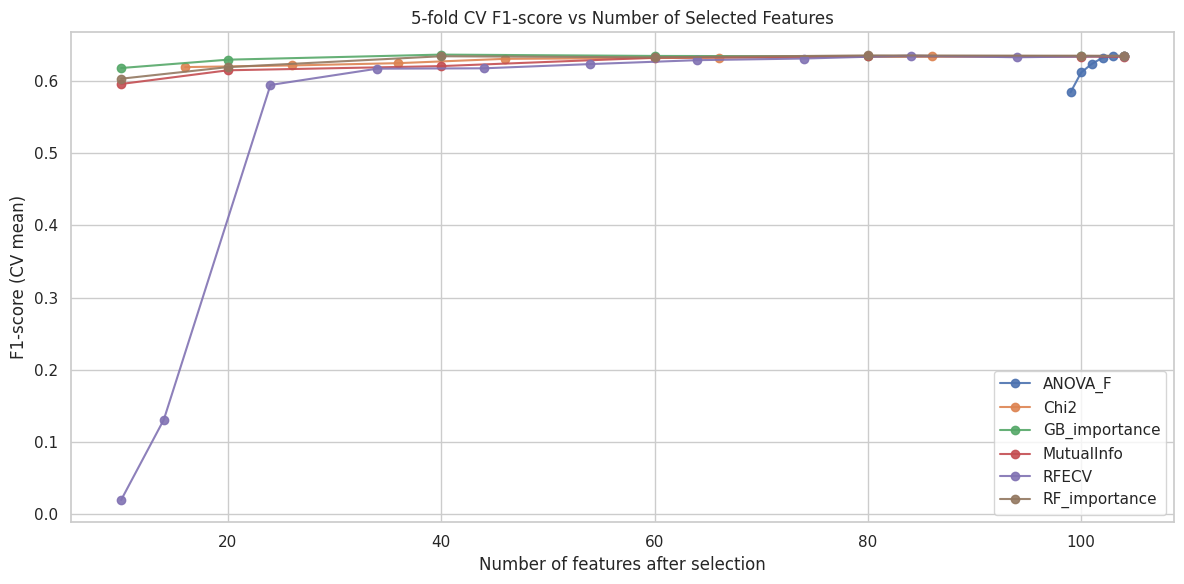

In [33]:
# Merge all feature-selection curves and plot performance vs number of features
curve_frames = [anova_df, chi_df, mi_df, rf_df, gb_df]
fs_curve = pd.concat(curve_frames, ignore_index=True)

# Keep a common x-axis column name
plot_df = fs_curve[["method", "total_features_after_selection", "cv_f1_mean"]].copy()
plot_df = pd.concat([plot_df, rfecv_curve], ignore_index=True)

summary_best = (
    plot_df.sort_values("cv_f1_mean", ascending=False)
    .groupby("method", as_index=False)
    .first()[["method", "total_features_after_selection", "cv_f1_mean"]]
    .rename(columns={
        "total_features_after_selection": "best_feature_count",
        "cv_f1_mean": "best_cv_f1"
    })
)

print("Best result per feature-selection method:")
display(summary_best.sort_values("best_cv_f1", ascending=False))

plt.figure(figsize=(12, 6))
for method_name, g in plot_df.groupby("method"):
    g = g.sort_values("total_features_after_selection")
    plt.plot(
        g["total_features_after_selection"],
        g["cv_f1_mean"],
        marker="o",
        label=method_name,
        alpha=0.9
    )

plt.title("5-fold CV F1-score vs Number of Selected Features")
plt.xlabel("Number of features after selection")
plt.ylabel("F1-score (CV mean)")
plt.legend()
plt.tight_layout()
plt.show()


**Phân tích tổng hợp phần chọn đặc trưng:**
Biểu đồ so sánh giúp xác định rõ phương pháp nào đạt F1 cao nhất tại cùng mức số chiều. Thực tế thường có vùng "điểm ngọt" nơi tăng thêm đặc trưng không cải thiện đáng kể F1. Khi chọn phương pháp cuối cùng, nên cân nhắc đồng thời: (1) F1 cao, (2) số đặc trưng nhỏ, (3) độ ổn định giữa các fold.

## 5.7 Dimensionality Reduction: PCA
PCA tìm các trục trực giao (principal components) để tối đa phương sai dữ liệu chiếu lên:
$$
\mathbf{z}_i = \mathbf{W}^T(\mathbf{x}_i - \boldsymbol{\mu})
$$
Trong đó $\mathbf{W}$ chứa các vector riêng của ma trận hiệp phương sai.

Ta đánh giá ảnh hưởng của số thành phần PCA tới F1 bằng 5-fold CV.

PCA CV results:


,method,n_components,cv_f1_mean,cv_f1_std
0,PCA,5,0.539353,0.015083
1,PCA,10,0.599644,0.009847
2,PCA,20,0.621837,0.015923
3,PCA,30,0.626813,0.013566
4,PCA,40,0.632110,0.009709
5,PCA,60,0.634566,0.009775


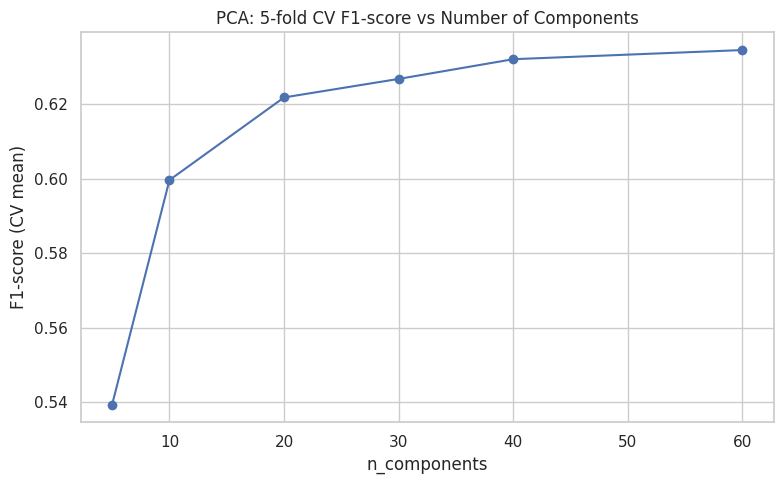

In [34]:
# PCA evaluation (dense one-hot for compatibility)
pca_rows = []

preprocessor_dense = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), fs_categorical_cols)
])

X_probe_dense = preprocessor_dense.fit_transform(X_fs)
max_comp = X_probe_dense.shape[1]

candidate_components = [5, 10, 20, 30, 40, 60]
k_pca_values = [k for k in candidate_components if k < max_comp]
if max_comp not in k_pca_values and max_comp <= 80:
    k_pca_values.append(max_comp)

for n_comp in k_pca_values:
    pca_pipe = Pipeline([
        ("prep", preprocessor_dense),
        ("pca", PCA(n_components=n_comp, random_state=42)),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pca_pipe, X_fs, y_fs)
    pca_rows.append({
        "method": "PCA",
        "n_components": n_comp,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

pca_df = pd.DataFrame(pca_rows)
print("PCA CV results:")
display(pca_df)

plt.figure(figsize=(8, 5))
plt.plot(pca_df["n_components"], pca_df["cv_f1_mean"], marker="o")
plt.title("PCA: 5-fold CV F1-score vs Number of Components")
plt.xlabel("n_components")
plt.ylabel("F1-score (CV mean)")
plt.tight_layout()
plt.show()


**Phân tích kết quả (PCA):**
Nếu F1 giữ gần mức cao nhất ở số thành phần thấp, PCA đang nén thông tin hiệu quả và giảm nhiễu/đa cộng tuyến. Ngược lại, nếu F1 giảm rõ khi giảm số thành phần, dữ liệu có thể cần không gian chiều cao hơn để giữ ranh giới phân lớp. Kết quả này giúp chọn `n_components` phù hợp cho cân bằng giữa hiệu năng và tốc độ.

## 5.8 Dimensionality Reduction for Visualization: t-SNE
`t-SNE` là kỹ thuật phi tuyến cho trực quan hóa, tối ưu bảo toàn lân cận cục bộ khi ánh xạ dữ liệu từ không gian cao chiều xuống 2D/3D.

Hàm mục tiêu dựa trên độ lệch giữa phân phối xác suất cặp điểm ở không gian gốc và không gian nhúng (KL divergence):
$$
KL(P\|Q) = \sum_{i \ne j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

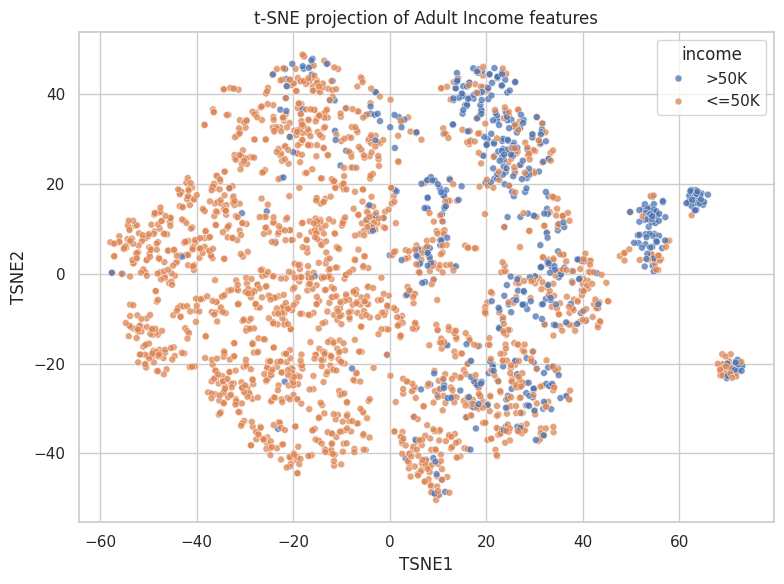

In [35]:
# t-SNE visualization on a manageable sample
viz_n = min(2500, len(X_fs))
X_viz = X_fs.iloc[:viz_n].copy()
y_viz = y_fs.iloc[:viz_n].copy()

# Dense transformed features then optional PCA pre-reduction for speed
X_viz_dense = preprocessor_dense.fit_transform(X_viz)

pca_for_tsne = PCA(n_components=min(30, X_viz_dense.shape[1]-1), random_state=42)
X_viz_pca = pca_for_tsne.fit_transform(X_viz_dense)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne = tsne.fit_transform(X_viz_pca)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "income": y_viz.map({0: "<=50K", 1: ">50K"}).values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="income", s=25, alpha=0.75)
plt.title("t-SNE projection of Adult Income features")
plt.tight_layout()
plt.show()


**Phân tích kết quả (t-SNE):**
Biểu đồ t-SNE giúp quan sát mức tách cụm trực quan giữa hai lớp thu nhập. Nếu hai màu chồng lấn mạnh, bài toán có ranh giới phức tạp và mô hình tuyến tính có thể gặp khó khăn. Nếu xuất hiện các vùng tách tương đối rõ, điều đó gợi ý dữ liệu có cấu trúc hữu ích cho phân loại. Lưu ý t-SNE phục vụ trực quan hóa, không nên dùng trực tiếp như bước biến đổi đặc trưng chính cho mô hình dự báo cuối cùng.

## 5.9 UMAP (for larger datasets)
UMAP là kỹ thuật giảm chiều phi tuyến dựa trên học đa tạp, thường nhanh hơn t-SNE và giữ được cả cấu trúc cục bộ lẫn một phần cấu trúc toàn cục.

Ý tưởng chính: xây dựng đồ thị lân cận mờ trong không gian gốc, sau đó tối ưu biểu diễn chiều thấp để bảo toàn cấu trúc đồ thị này.

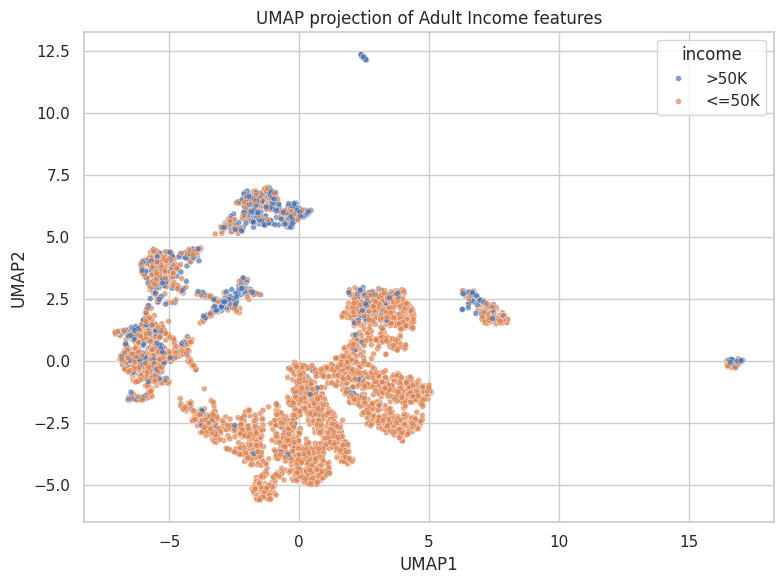

In [36]:
# UMAP visualization if the package is available
try:
    import umap

    umap_n = min(8000, len(X_fs))
    X_um = X_fs.iloc[:umap_n].copy()
    y_um = y_fs.iloc[:umap_n].copy()

    X_um_dense = preprocessor_dense.fit_transform(X_um)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )
    X_umap = reducer.fit_transform(X_um_dense)
    
    umap_df = pd.DataFrame({
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "income": y_um.map({0: "<=50K", 1: ">50K"}).values
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="income", s=18, alpha=0.7)
    plt.title("UMAP projection of Adult Income features")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("UMAP is skipped because the package is unavailable or failed to run.")
    print("Reason:", str(e))


**Phân tích kết quả (UMAP):**
Với tập dữ liệu tương đối lớn, UMAP thường cho thời gian chạy tốt hơn t-SNE và biểu đồ ổn định hơn khi thay đổi seed. Nếu cụm dữ liệu thể hiện ranh giới rõ hơn t-SNE, ta có thêm bằng chứng về cấu trúc manifold trong dữ liệu. Tuy nhiên tương tự t-SNE, UMAP chủ yếu dùng cho khám phá trực quan và hỗ trợ diễn giải.

# 6. [Nâng cao] Xử lý mất cân bằng lớp (SMOTE, ADASYN, Random Under-sampling).
## 6.1 [Nâng cao] Class Imbalance Handling: SMOTE
SMOTE sinh mẫu thiểu số mới bằng nội suy giữa một điểm thiểu số và các láng giềng gần:
$$
\mathbf{x}_{new} = \mathbf{x}_i + \lambda(\mathbf{x}_{nn}-\mathbf{x}_i),\quad \lambda\in(0,1)
$$
Mục tiêu là tăng đại diện lớp thiểu số và cải thiện Recall/F1-macro.

In [37]:
# Shared preprocessing for imbalance experiments (dense output for resampling methods)
imb_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), fs_categorical_cols)
])

# We evaluate on untouched test set as required
strategies = {
    "Baseline (no resampling)": None,
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42)
}

imb_rows = []
for name, sampler in strategies.items():
    steps = [("prep", imb_preprocessor)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", LogisticRegression(max_iter=1500, solver="liblinear", random_state=42)))

    model = ImbPipeline(steps)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    imb_rows.append({
        "strategy": name,
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "auc_roc": roc_auc_score(y_test, y_prob)
    })

imbalance_df = pd.DataFrame(imb_rows).sort_values("f1_macro", ascending=False)
print("Evaluation on untouched test set:")
display(imbalance_df)

Evaluation on untouched test set:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
0,Baseline (no resampling),0.794292,0.741116,0.761890,0.897290
3,RandomUnderSampler,0.738286,0.818136,0.754844,0.897048
1,SMOTE,0.736706,0.813840,0.753580,0.895155
2,ADASYN,0.720521,0.807435,0.728480,0.891644


**Phân tích kết quả (SMOTE):**
So với baseline, SMOTE thường cải thiện Recall của lớp thiểu số và vì vậy có thể tăng F1-macro. Nếu Precision giảm nhẹ nhưng Recall tăng nhiều, đó là trade-off thường gặp và có thể chấp nhận tùy mục tiêu nghiệp vụ. Chỉ số AUC-ROC giúp kiểm tra thêm chất lượng xếp hạng xác suất thay vì chỉ dựa trên ngưỡng phân loại cố định.

## 6.2 [Nâng cao] Class Imbalance Handling: ADASYN
ADASYN mở rộng ý tưởng SMOTE bằng cách sinh nhiều mẫu hơn ở những vùng "khó học" (nơi lớp thiểu số bị bao quanh bởi lớp đa số). Nhờ đó mô hình được tập trung cải thiện ở các biên quyết định phức tạp.

In [38]:
# Show ADASYN-only row for focused interpretation
adasyn_row = imbalance_df[imbalance_df["strategy"] == "ADASYN"].copy()
print("ADASYN result:")
display(adasyn_row)

ADASYN result:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
2,ADASYN,0.720521,0.807435,0.72848,0.891644


**Phân tích kết quả (ADASYN):**
Nếu ADASYN tốt hơn SMOTE, dữ liệu nhiều khả năng có vùng biên phân lớp khó và không đồng đều. Ngược lại, nếu ADASYN kém hơn, có thể do việc sinh mẫu tập trung quá mức vào vùng nhiễu làm giảm độ chính xác tổng thể. Khi đó SMOTE hoặc chiến lược cân bằng đơn giản có thể ổn định hơn.

## 6.3 [Nâng cao] Class Imbalance Handling: Random Under-sampling
Random Under-sampling giảm ngẫu nhiên số mẫu lớp đa số để cân bằng tỷ lệ lớp. Ưu điểm là nhanh, đơn giản; nhược điểm là có thể làm mất thông tin quan trọng của lớp đa số.

In [39]:
# Show Random Under-sampling row for focused interpretation
rus_row = imbalance_df[imbalance_df["strategy"] == "RandomUnderSampler"].copy()
print("Random Under-sampling result:")
display(rus_row)

Random Under-sampling result:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
3,RandomUnderSampler,0.738286,0.818136,0.754844,0.897048


**Phân tích kết quả (Random Under-sampling):**
Nếu Recall tăng nhưng Precision hoặc AUC giảm đáng kể, nguyên nhân thường là mất thông tin từ lớp đa số sau khi cắt bớt dữ liệu. Phương pháp này phù hợp khi dữ liệu rất lớn hoặc cần huấn luyện nhanh, nhưng nên so sánh cẩn thận với các kỹ thuật over-sampling để tránh suy giảm hiệu năng tổng thể.

## 6.4 [Nâng cao] Vì sao không resampling trước khi chia train/test?
Nếu resampling được thực hiện **trước** khi tách train/test, các mẫu tổng hợp (hoặc mẫu giữ lại sau under-sampling) có thể làm rò rỉ thông tin thống kê từ toàn bộ dữ liệu sang tập test.

Hậu quả:
1. Đánh giá bị lạc quan giả tạo vì test không còn đại diện cho dữ liệu thực tế chưa thấy.
2. Mẫu tổng hợp có thể gián tiếp "gần" các điểm test, làm tăng điểm số không công bằng.
3. Quy trình triển khai thực tế bị sai lệch, vì production luôn cần dự đoán trên dữ liệu gốc chưa tái cân bằng.

Do đó, quy trình đúng là: **split train/test trước**, sau đó chỉ resample trên tập train.

In [40]:
# Build final preprocessed dataset and save to data/tabular-data/processed
df_final = df.copy()
df_final = df_final.replace("?", np.nan)

# Impute missing values
cat_cols_with_nan = ["workclass", "occupation", "native-country"]
df_final[cat_cols_with_nan] = imputer_mode.fit_transform(df_final[cat_cols_with_nan])
df_final[numeric_cols] = imputer_mean.fit_transform(df_final[numeric_cols])

# Remove outliers with Isolation Forest
iso_final = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_final.fit_predict(df_final[numeric_cols]) == 1
df_final = df_final.loc[outlier_mask].reset_index(drop=True)

# Scale numeric features
scaler_final = StandardScaler()
df_final[numeric_cols] = scaler_final.fit_transform(df_final[numeric_cols])

# Create target label for encoding
income_map = {"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1}
df_final["income_bin"] = df_final["income"].map(income_map)

# Target encoding with CV to avoid leakage

def target_encode_cv_frame(df_input, col, target_col, n_splits=5):
    df_res = pd.DataFrame(index=df_input.index)
    df_res[f"{col}_target"] = 0.0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = df_input[target_col].mean()
    for train_idx, val_idx in kf.split(df_input):
        mean_map = df_input.iloc[train_idx].groupby(col)[target_col].mean()
        df_res.loc[df_input.index[val_idx], f"{col}_target"] = df_input.iloc[val_idx][col].map(mean_map)
    df_res[f"{col}_target"] = df_res[f"{col}_target"].fillna(global_mean)
    return df_res

occ_target = target_encode_cv_frame(df_final, "occupation", "income_bin")
country_target = target_encode_cv_frame(df_final, "native-country", "income_bin")

# Ordinal encoding for education
edu_map = {
    "Preschool": 1,
    "1st-4th": 2,
    "5th-6th": 3,
    "7th-8th": 4,
    "9th": 5,
    "10th": 6,
    "11th": 7,
    "12th": 8,
    "HS-grad": 9,
    "Some-college": 10,
    "Assoc-voc": 11,
    "Assoc-acdm": 12,
    "Bachelors": 13,
    "Masters": 14,
    "Prof-school": 15,
    "Doctorate": 16,
}
df_final["education_ordinal"] = df_final["education"].map(edu_map)

# One-hot encoding for remaining low-cardinality features
low_card_cols = ["workclass", "marital-status", "relationship", "race", "sex"]
df_low_card = pd.get_dummies(df_final[low_card_cols], prefix=low_card_cols, drop_first=True)

# Use ordinal education and drop the redundant education-num
numeric_cols_final = [col for col in numeric_cols if col != "education-num"]

# Assemble processed dataset
processed_frames = [
    df_final[numeric_cols_final],
    df_final[["education_ordinal"]],
    occ_target,
    country_target,
    df_low_card,
    df_final[["income", "income_bin"]],
]

df_processed = pd.concat(processed_frames, axis=1)

output_dir = "../data/tabular-data/processed"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "adult_preprocessed.csv")
df_processed.to_csv(output_path, index=False)
print("Saved:", output_path)
print("Processed shape:", df_processed.shape)

Saved: ../data/tabular-data/processed/adult_preprocessed.csv
Processed shape: (46399, 33)
